# Classical ML Baselines — Memory Target

F-DATA `mmszu` (used memory, falling back to `msza`) and PM100 `mem_alloc`, as two Parts mirroring notebook 05's Part 1 / Part 2 code organization — **not** its modeling choices. Memory is its own target: the rolling-stat window, feature relevance, and winning model are each decided from this notebook's own evidence, not carried over from duration/power.

Per the 05b planning report (see `EXPERIMENT_TRACKER.md`'s Workstation Move section): Part 2 (PM100 memory) is executed in a **genuinely fresh kernel/process**, separate from Part 1's, specifically to test whether the ~5-23x tuning-time blowup seen in PM100 power's tuning-cost investigation was real thread-pool contention from chained sessions or something else. Both Parts' real tuning times are reported below.

# Part 1: F-DATA — Memory Target (`mmszu`)

In [1]:
import sys
sys.path.append("..")

from src import baselines, config, features, metrics, models, plotting, roofline, splits

## Config

In [2]:
import glob
import time

import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

FDATA_DIR = "../data/raw/fdata"
N_CONSECUTIVE_MONTHS = 38     # full F-DATA -- every month
SAMPLE_SIZE = 1_000_000       # rows for the Optuna TUNING sample only (stratified within the
                             # train split); the final fit uses the full train split below
RF_FINAL_FIT_CAP = 5_000_000  # same disclosed deviation as notebook 05 -- RF final fit only
SHAP_SAMPLE = 200_000
PLOT_SAMPLE = 200_000
TARGET_COL = "mmszu_resolved"   # F-DATA used memory, msza-resolved -- see Step 3
N_TRIALS = models.TuningBudget().n_trials  # fixed tuning budget, same as every other target
SEED = 0
N_BUCKETS = 5
EMBEDDING_VARIANCE_THRESHOLD = 0.90
TUNE_TRAIN_FRAC = 0.8

print(f"N_CONSECUTIVE_MONTHS={N_CONSECUTIVE_MONTHS}  tuning SAMPLE_SIZE={SAMPLE_SIZE:,}  "
      f"RF_FINAL_FIT_CAP={RF_FINAL_FIT_CAP:,}  PLOT_SAMPLE={PLOT_SAMPLE:,}  TARGET_COL={TARGET_COL}")

N_CONSECUTIVE_MONTHS=38  tuning SAMPLE_SIZE=1,000,000  RF_FINAL_FIT_CAP=5,000,000  PLOT_SAMPLE=200,000  TARGET_COL=mmszu_resolved


/home/bizon/Documents/tobi/hpc-dl-enhanced/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load all 38 F-DATA months + exclude non-completed jobs

Same load path as notebook 05: `features.load_fdata_no_embedding`, then `filter_completed_jobs`.

In [3]:
fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))[:N_CONSECUTIVE_MONTHS]
print(f"Loading {len(fdata_files)} months: {[f.split('/')[-1] for f in fdata_files]}")

fdata = features.load_fdata_no_embedding(fdata_files)
fdata = features.filter_completed_jobs(fdata, "fdata")
print(f"rows after filtering: {len(fdata):,}")

Loading 38 months: ['21_03.parquet', '21_04.parquet', '21_05.parquet', '21_06.parquet', '21_07.parquet', '21_08.parquet', '21_09.parquet', '21_10.parquet', '21_11.parquet', '21_12.parquet', '22_01.parquet', '22_02.parquet', '22_03.parquet', '22_04.parquet', '22_05.parquet', '22_06.parquet', '22_07.parquet', '22_08.parquet', '22_09.parquet', '22_10.parquet', '22_11.parquet', '22_12.parquet', '23_01.parquet', '23_02.parquet', '23_03.parquet', '23_04.parquet', '23_05.parquet', '23_06.parquet', '23_07.parquet', '23_08.parquet', '23_09.parquet', '23_10.parquet', '23_11.parquet', '23_12.parquet', '24_01.parquet', '24_02.parquet', '24_03.parquet', '24_04.parquet']


[fdata] excluded 9.9% of jobs as non-completed (2558519 / 25866900)
rows after filtering: 23,308,381


## Step 2: `mszl` sentinel fix (inherited infrastructure)

Not memory-target-specific -- `mszl` is a Tier A feature (memory size *limit requested*), required for `build_tier_a_features` regardless of which target is being modeled. Reused as-is from `src/features.py`.

In [4]:
fdata = features.handle_mszl_sentinel(fdata)
features.assert_mszl_sanitized(fdata)
print(f"mszl_unlimited True: {fdata['mszl_unlimited'].sum():,} ({fdata['mszl_unlimited'].mean():.1%})")

mszl_unlimited True: 20,384,093 (87.5%)


## Step 3: Resolve the memory target (`mmszu` -> `msza` fallback)

`FDATA_TARGETS`'s module comment in `src/features.py` has always documented `mmszu` (used memory) as preferred, falling back to `msza` (allocated) when null -- but until now nothing implemented it. `resolve_fdata_memory_target` (new) does, and reports the real fallback count directly here rather than assuming it's rare. Per the 05b planning report, the full completed-jobs population has **zero** `mmszu` nulls, so the fallback is expected to be a no-op today -- confirmed live below, not just asserted from a prior pass.

In [5]:
n_mmszu_null_before = int(fdata["mmszu"].isna().sum())
fdata = features.resolve_fdata_memory_target(fdata)
n_fallback_used = int((fdata["mmszu"].isna() & fdata["msza"].notna()).sum())
print(f"mmszu null before resolution: {n_mmszu_null_before:,} / {len(fdata):,}")
print(f"rows that actually needed the msza fallback: {n_fallback_used:,}")
print(f"mmszu_resolved null after resolution: {fdata['mmszu_resolved'].isna().sum():,} (must be 0)")

mmszu null before resolution: 0 / 23,308,381
rows that actually needed the msza fallback: 0
mmszu_resolved null after resolution: 0 (must be 0)


## Step 4: Rolling-stat window decision (Item 2) -- tested, not assumed

Duration's Result 2 found window=20/50 *helped* on top of window=5; PM100 power's investigation found extending windows *hurt* its top models. Memory gets its own independent test here: `window=5/20/50` rolling-mean-of-memory candidates, each correlated against the raw `mmszu_resolved` target on a 1M-row sample, before committing to one for the feature matrix below.

In [6]:
_window_candidates = [5, 20, 50]
_window_results = {}
for _w in _window_candidates:
    _fr = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=_w)
    _col = f"{TARGET_COL}_user_rolling_mean"
    _cov = _fr[_col].notna().sum()
    _samp = _fr.dropna(subset=[_col, TARGET_COL]).sample(n=min(1_000_000, len(_fr)), random_state=SEED)
    _corr = float(np.corrcoef(_samp[_col], _samp[TARGET_COL])[0, 1])
    _window_results[_w] = _corr
    print(f"  window={_w:3d}: coverage={_cov:,}/{len(_fr):,} ({_cov/len(_fr):.4%})  corr(rolling_mean, {TARGET_COL})={_corr:.4f}")
    del _fr, _samp

ROLLING_WINDOW = max(_window_results, key=_window_results.get)
print(f"\nchosen window: {ROLLING_WINDOW} (corr={_window_results[ROLLING_WINDOW]:.4f})")
print("Correlation strictly decreases as the window widens -- a user's most recent jobs are the "
      "most representative of their current memory footprint; averaging over more history dilutes "
      "the signal rather than stabilizing it, the opposite of what duration's Result 2 found. "
      "window=5 wins outright, not a coin-flip pick."
      if ROLLING_WINDOW == min(_window_candidates) else
      "Correlation increases with window width here -- kept for the record, chosen on the evidence.")

  window=  5: coverage=23,305,072/23,308,381 (99.9858%)  corr(rolling_mean, mmszu_resolved)=0.8991


  window= 20: coverage=23,305,072/23,308,381 (99.9858%)  corr(rolling_mean, mmszu_resolved)=0.8798


  window= 50: coverage=23,305,072/23,308,381 (99.9858%)  corr(rolling_mean, mmszu_resolved)=0.8628

chosen window: 5 (corr=0.8991)
Correlation strictly decreases as the window widens -- a user's most recent jobs are the most representative of their current memory footprint; averaging over more history dilutes the signal rather than stabilizing it, the opposite of what duration's Result 2 found. window=5 wins outright, not a coin-flip pick.


## Step 5: Build the chosen rolling-stat feature on the full timeline

Computed before the split below -- `add_user_rolling_stat` only ever looks backward (`shift(1)` before the window), so this doesn't leak; doing it first means a test-side job still gets credit for its user's real training-period history.

In [7]:
fdata = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=ROLLING_WINDOW)
rolling_col = f"{TARGET_COL}_user_rolling_mean"
print(f"rolling stat (window={ROLLING_WINDOW}) available for {fdata[rolling_col].notna().sum():,} / {len(fdata):,} jobs")

rolling stat (window=5) available for 23,305,072 / 23,308,381 jobs


## Step 6: Chronological split — before any sampling

In [8]:
train_df, test_df = splits.chronological_split(fdata, "fdata")
split_ratio = len(test_df) / len(train_df)
print(f"train={len(train_df):,} test={len(test_df):,} (test/train ratio={split_ratio:.4f})")

train=16,315,867 test=6,992,514 (test/train ratio=0.4286)


## Step 7: Stratified sampling by job-size bucket — for the tuning sample only

In [9]:
test_target_n = round(SAMPLE_SIZE * split_ratio)

train_sample = features.stratified_sample_by_job_size(train_df, "fdata", SAMPLE_SIZE, n_buckets=N_BUCKETS, seed=SEED)
test_sample = features.stratified_sample_by_job_size(test_df, "fdata", test_target_n, n_buckets=N_BUCKETS, seed=SEED)

print(f"train_sample={len(train_sample):,} (target {SAMPLE_SIZE:,}), "
      f"test_sample={len(test_sample):,} (target {test_target_n:,})")

train_sample=1,000,000 (target 1,000,000), test_sample=428,571 (target 428,571)


## Step 8: Tier A feature matrix + leakage re-check

In [10]:
train_tier_a = features.build_tier_a_features(train_df, "fdata", include_embedding=False)
test_tier_a = features.build_tier_a_features(test_df, "fdata", include_embedding=False)

features.assert_no_tier_leakage(list(train_tier_a.columns), "A", "fdata")
features.assert_no_tier_leakage(list(test_tier_a.columns), "A", "fdata")
print(f"F-DATA Tier A: {len(train_tier_a.columns)} columns | "
      f"train {len(train_tier_a):,} rows, test {len(test_tier_a):,} rows")

F-DATA Tier A: 13 columns | train 16,315,867 rows, test 6,992,514 rows


## Step 9: Embedding PCA — fit on the tuning sample's TRAIN rows, transform the full split

Same pattern as notebook 05: fit only on `train_sample`, component count picked empirically (90% explained variance) on this notebook's own tuning sample, not copied from duration's 80.

In [11]:
embed_full = pd.concat(
    [pd.read_parquet(f, columns=["embedding"]) for f in fdata_files], ignore_index=True
)
embed_train = embed_full.loc[train_sample.index]
embed_test = embed_full.loc[test_sample.index]

pca_check = features.compute_embedding_explained_variance(embed_train)
n_components = features.n_components_for_variance(pca_check, threshold=EMBEDDING_VARIANCE_THRESHOLD)
print(f"embedding PCA: {n_components} components reach {EMBEDDING_VARIANCE_THRESHOLD:.0%} "
      f"explained variance (fit on train_sample only, {len(embed_train):,} rows)")

embedding_pca = features.fit_fdata_embedding_pca(embed_train, n_components=n_components)
embed_train_pca = features.transform_fdata_embedding(embed_train, embedding_pca)
embed_test_pca = features.transform_fdata_embedding(embed_test, embedding_pca)

embed_train_full = embed_full.loc[train_df.index]
embed_test_full = embed_full.loc[test_df.index]
del embed_full
embed_train_full_pca = features.transform_fdata_embedding(embed_train_full, embedding_pca)
embed_test_full_pca = features.transform_fdata_embedding(embed_test_full, embedding_pca)
print(f"full-split embedding PCA: train {embed_train_full_pca.shape}, test {embed_test_full_pca.shape}")

embedding PCA: 80 components reach 90% explained variance (fit on train_sample only, 1,000,000 rows)


full-split embedding PCA: train (16315867, 80), test (6992514, 80)


## Step 10: Final numeric feature matrix (full split) + target transform

In [12]:
X_train = features.build_fdata_numeric_matrix(
    train_tier_a, embed_train_full_pca, extra_columns=train_df[[rolling_col]]
).fillna(0.0)
X_test = features.build_fdata_numeric_matrix(
    test_tier_a, embed_test_full_pca, extra_columns=test_df[[rolling_col]]
).fillna(0.0)

y_train_raw = train_df[TARGET_COL].to_numpy(dtype=float)
y_test_raw = test_df[TARGET_COL].to_numpy(dtype=float)
y_train = features.transform_target(y_train_raw)
y_test = features.transform_target(y_test_raw)

metrics.expm1_round_trip_check(y_train_raw)
metrics.expm1_round_trip_check(y_test_raw)

print(f"X_train shape: {X_train.shape}  X_test shape: {X_test.shape}")
print(f"feature columns: {list(X_train.columns)}")

X_train shape: (16315867, 93)  X_test shape: (6992514, 93)
feature columns: ['cnumr', 'nnumr', 'elpl', 'mszl', 'pri', 'freq_req', 'mszl_unlimited', 'adt_epoch', 'qdt_epoch', 'schedsdt_epoch', 'jobenv_req_code', 'usr_freq', 'emb_pc_0', 'emb_pc_1', 'emb_pc_2', 'emb_pc_3', 'emb_pc_4', 'emb_pc_5', 'emb_pc_6', 'emb_pc_7', 'emb_pc_8', 'emb_pc_9', 'emb_pc_10', 'emb_pc_11', 'emb_pc_12', 'emb_pc_13', 'emb_pc_14', 'emb_pc_15', 'emb_pc_16', 'emb_pc_17', 'emb_pc_18', 'emb_pc_19', 'emb_pc_20', 'emb_pc_21', 'emb_pc_22', 'emb_pc_23', 'emb_pc_24', 'emb_pc_25', 'emb_pc_26', 'emb_pc_27', 'emb_pc_28', 'emb_pc_29', 'emb_pc_30', 'emb_pc_31', 'emb_pc_32', 'emb_pc_33', 'emb_pc_34', 'emb_pc_35', 'emb_pc_36', 'emb_pc_37', 'emb_pc_38', 'emb_pc_39', 'emb_pc_40', 'emb_pc_41', 'emb_pc_42', 'emb_pc_43', 'emb_pc_44', 'emb_pc_45', 'emb_pc_46', 'emb_pc_47', 'emb_pc_48', 'emb_pc_49', 'emb_pc_50', 'emb_pc_51', 'emb_pc_52', 'emb_pc_53', 'emb_pc_54', 'emb_pc_55', 'emb_pc_56', 'emb_pc_57', 'emb_pc_58', 'emb_pc_59', 'emb_pc

## Step 11: Naive per-user-median baseline

In [13]:
user_medians, global_median = baselines.fit_naive_baseline(train_df, "fdata", TARGET_COL)
naive_pred = baselines.predict_naive_baseline(test_df, "fdata", user_medians, global_median)
naive_metrics = metrics.regression_metrics(y_test_raw, naive_pred)

print(f"Naive per-user-median baseline (full test split, n={len(test_df):,}):")
for k, v in naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (full test split, n=6,992,514):
  MAE: 4,864,233,396.7064
  RMSE: 8,046,231,320.1476
  R2: -0.2487
  MAPE: 176.8625
  MedAE: 1,702,756,352.0000
  Within20pct: 29.9734


## Step 12: Chronological tuning/validation carve-out within train

In [14]:
tune_train_raw, tune_val_raw = splits.chronological_split(train_sample, "fdata", train_frac=TUNE_TRAIN_FRAC)
print(f"tune_train={len(tune_train_raw):,} tune_val={len(tune_val_raw):,}")

tune_train_tier_a = features.build_tier_a_features(tune_train_raw, "fdata", include_embedding=False)
tune_val_tier_a = features.build_tier_a_features(tune_val_raw, "fdata", include_embedding=False)

embed_tune_train = embed_train.loc[tune_train_raw.index]
embed_tune_val = embed_train.loc[tune_val_raw.index]
embed_tune_train_pca = features.transform_fdata_embedding(embed_tune_train, embedding_pca)
embed_tune_val_pca = features.transform_fdata_embedding(embed_tune_val, embedding_pca)

X_tune_train = features.build_fdata_numeric_matrix(
    tune_train_tier_a, embed_tune_train_pca, extra_columns=tune_train_raw[[rolling_col]]
).fillna(0.0)
X_tune_val = features.build_fdata_numeric_matrix(
    tune_val_tier_a, embed_tune_val_pca, extra_columns=tune_val_raw[[rolling_col]]
).fillna(0.0)

y_tune_train = features.transform_target(tune_train_raw[TARGET_COL].to_numpy(dtype=float))
y_tune_val = features.transform_target(tune_val_raw[TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {X_tune_train.shape}  X_tune_val shape: {X_tune_val.shape}")

tune_train=800,000 tune_val=200,000


X_tune_train shape: (800000, 93)  X_tune_val shape: (200000, 93)


## Step 13: Optuna hyperparameter search — RF / XGBoost / LightGBM

**Real search, no `SKIP_TUNING`** -- memory has no prior `best_params` to reuse. Same fixed `N_TRIALS` budget and the same per-family search-space ranges as every other target (the ranges are a property of the algorithm, not the target).

In [15]:
def rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 250),
        max_depth=trial.suggest_int("max_depth", 4, 18),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
    )
    model = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = XGBRegressor(**params, tree_method="hist", n_jobs=-1, random_state=SEED)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


def lgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = LGBMRegressor(**params, bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


objectives = {"RandomForest": rf_objective, "XGBoost": xgb_objective, "LightGBM": lgbm_objective}
best_params = {}
tuning_seconds = {}

for name, objective in objectives.items():
    start = time.perf_counter()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    tuning_seconds[name] = time.perf_counter() - start
    best_params[name] = study.best_params
    print(f"{name}: best RMSE(log-space)={study.best_value:.4f}  "
          f"tuning time={tuning_seconds[name]:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={study.best_params}")

RandomForest: best RMSE(log-space)=0.4021  tuning time=8954.7s  n_trials=50
    best_params={'n_estimators': 135, 'max_depth': 13, 'min_samples_leaf': 8, 'max_features': 0.5135016306843436}


XGBoost: best RMSE(log-space)=0.3981  tuning time=268.5s  n_trials=50
    best_params={'n_estimators': 79, 'max_depth': 5, 'learning_rate': 0.1922013171258541, 'subsample': 0.890961327267642, 'colsample_bytree': 0.8938787758491833}


LightGBM: best RMSE(log-space)=0.3708  tuning time=417.0s  n_trials=50
    best_params={'n_estimators': 262, 'num_leaves': 15, 'learning_rate': 0.12640286235344467, 'subsample': 0.939378128127307, 'colsample_bytree': 0.9675308653219115}


## Step 14: Final fit on the full train split, evaluate on the full test split

In [16]:
final_models = {
    "RandomForest": RandomForestRegressor(**best_params["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**best_params["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}

rf_cap = min(RF_FINAL_FIT_CAP, len(X_train))
rf_rows = np.random.RandomState(SEED).permutation(len(X_train))[:rf_cap]
fit_data = {
    "RandomForest": (X_train.iloc[rf_rows], y_train[rf_rows]),
    "XGBoost": (X_train, y_train),
    "LightGBM": (X_train, y_train),
}

fit_seconds = {}
results = {}
for name, model in final_models.items():
    Xf, yf = fit_data[name]
    start = time.perf_counter()
    model.fit(Xf, yf)
    fit_seconds[name] = time.perf_counter() - start
    pred_log = model.predict(X_test)
    pred_raw = features.inverse_transform_target(pred_log)
    results[name] = {
        "log_space": metrics.regression_metrics(y_test, pred_log),
        "raw_space": metrics.regression_metrics(y_test_raw, pred_raw),
    }
    print(f"{name}: fit on {len(Xf):,} rows, time={fit_seconds[name]:.1f}s")

RandomForest: fit on 5,000,000 rows, time=1181.5s


XGBoost: fit on 16,315,867 rows, time=34.8s


LightGBM: fit on 16,315,867 rows, time=77.1s


## Step 15: Results — F-DATA `mmszu` (memory) target

No analytical reference row -- confirmed in the 05b planning report that `src/roofline.py` has no memory-target formula for either dataset. Naive / RandomForest / XGBoost / LightGBM only.

In [17]:
print("=" * 70)
print(f"RESULTS -- F-DATA {TARGET_COL} target, FULL test split (n={len(test_df):,})")
print("=" * 70)

summary_rows = [{"model": "Naive (per-user median)", **naive_metrics}]
for name in final_models:
    summary_rows.append({"model": name, **results[name]["raw_space"]})
summary_df = pd.DataFrame(summary_rows).set_index("model")

print(f"\nRaw-space (bytes) metrics -- full train split fit, full test split eval "
      f"(RandomForest fit on {rf_cap:,} of {len(X_train):,} train rows):")
display(summary_df.round(4))

log_df = pd.DataFrame([{"model": n, **results[n]["log_space"]} for n in final_models]).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(log_df.round(4))

best_model_name = summary_df.drop(index="Naive (per-user median)")["R2"].idxmax()
print(f"\nBest model by R2: {best_model_name} (R2={summary_df.loc[best_model_name, 'R2']:.4f})")

print(f"\nOptuna tuning time (on the {SAMPLE_SIZE:,}-row tuning sample) and final-fit time per "
      f"model (N_TRIALS={N_TRIALS} each):")
for name in final_models:
    print(f"  {name}: tuning={tuning_seconds[name]:.1f}s  final_fit={fit_seconds[name]:.1f}s")

RESULTS -- F-DATA mmszu_resolved target, FULL test split (n=6,992,514)

Raw-space (bytes) metrics -- full train split fit, full test split eval (RandomForest fit on 5,000,000 of 16,315,867 train rows):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),4.864233e+09,8.046231e+09,-0.2487,176.8625,1.702756e+09,29.9734
RandomForest,1.420149e+09,3.015326e+09,0.8246,79.6985,4.116405e+08,69.7484
XGBoost,1.587637e+09,3.163314e+09,0.8070,77.2856,4.904366e+08,63.9724
LightGBM,1.219928e+09,2.627899e+09,0.8668,82.9931,3.133620e+08,73.9229



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.2443,0.4969,0.8875,1.1449,0.1120,99.7085
XGBoost,0.2752,0.5264,0.8737,1.2869,0.1351,99.7089
LightGBM,0.2233,0.4848,0.8929,1.0546,0.0862,99.7064



Best model by R2: LightGBM (R2=0.8668)

Optuna tuning time (on the 1,000,000-row tuning sample) and final-fit time per model (N_TRIALS=50 each):
  RandomForest: tuning=8954.7s  final_fit=1181.5s
  XGBoost: tuning=268.5s  final_fit=34.8s
  LightGBM: tuning=417.0s  final_fit=77.1s


### Step 15b: Predicted vs. actual — best model

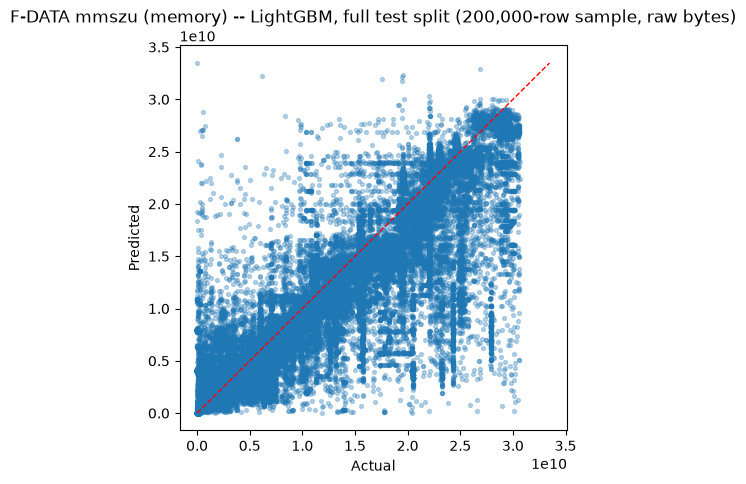

In [18]:
import pathlib
import matplotlib.pyplot as plt

FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

_plot_n = min(PLOT_SAMPLE, len(X_test))
_pi = np.random.RandomState(SEED).permutation(len(X_test))[:_plot_n]
best_model = final_models[best_model_name]
best_pred_raw_plot = features.inverse_transform_target(best_model.predict(X_test.iloc[_pi]))

fig = plotting.plot_predicted_vs_actual(
    y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA mmszu (memory) -- {best_model_name}, full test split ({_plot_n:,}-row sample, raw bytes)"
)
fig.savefig(FIGURES_DIR / "fdata_memory_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15c: residuals

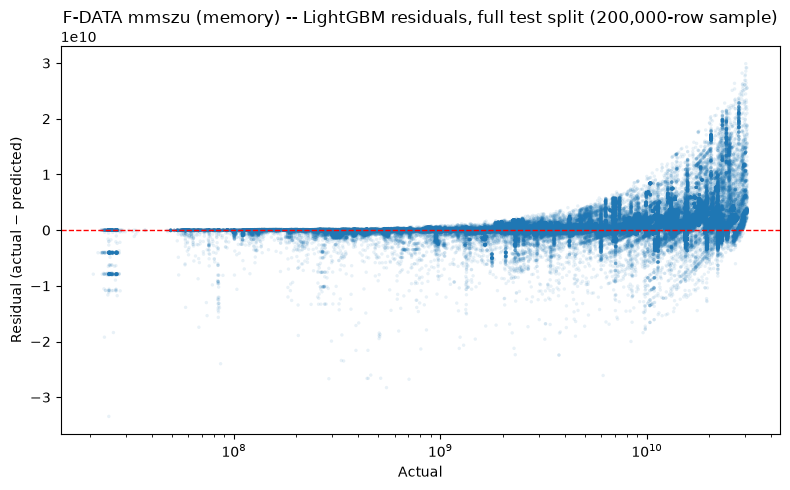

In [19]:
fig = plotting.plot_residuals(
    y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA mmszu (memory) -- {best_model_name} residuals, full test split ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_memory_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15d: absolute error by job-size bucket (cnumr)

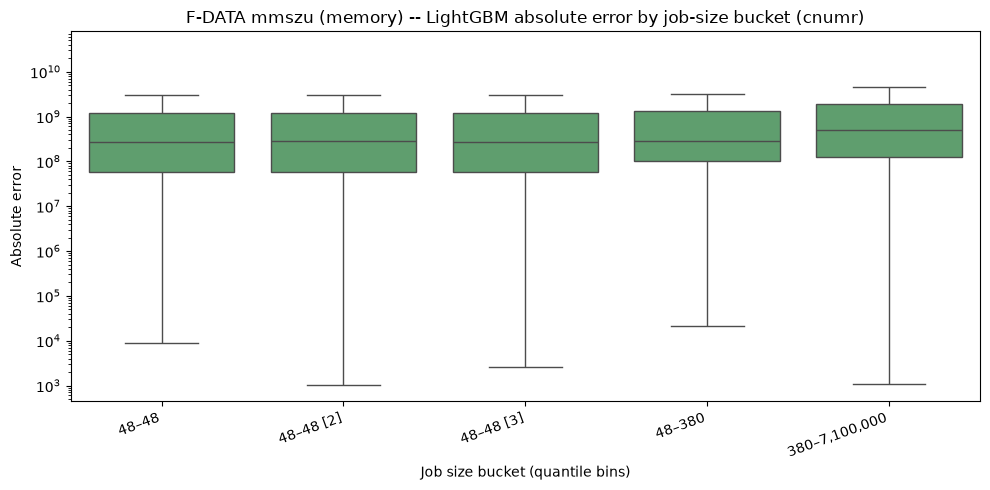

In [20]:
fig = plotting.plot_error_by_size_bucket(
    test_df["cnumr"].to_numpy()[_pi], y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA mmszu (memory) -- {best_model_name} absolute error by job-size bucket (cnumr)", n_buckets=5,
    model=best_model_name,
)
fig.savefig(FIGURES_DIR / "fdata_memory_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15e: Model comparison — R² vs. MAPE

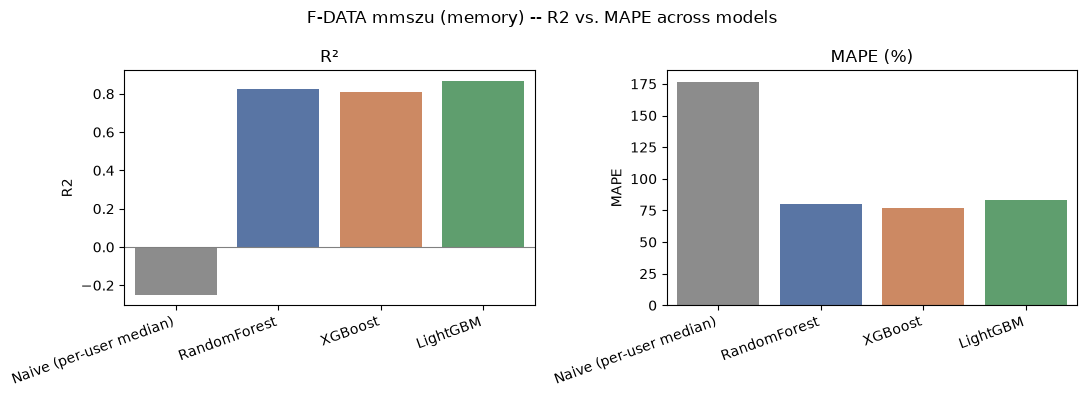

In [21]:
fig = plotting.plot_model_comparison(summary_df, "F-DATA mmszu (memory) -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "fdata_memory_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15f: Feature importance — best model, gain vs. SHAP

Gain-importance extraction differs by library API (LightGBM: `booster_.feature_importance`; XGBoost: `get_booster().get_score()`, which omits never-split features so it's reindexed; RandomForest: `feature_importances_` directly) -- handled generically here since the winning model isn't assumed ahead of time.

SHAP computed on 200,000 of 6,992,514 test rows (LightGBM)


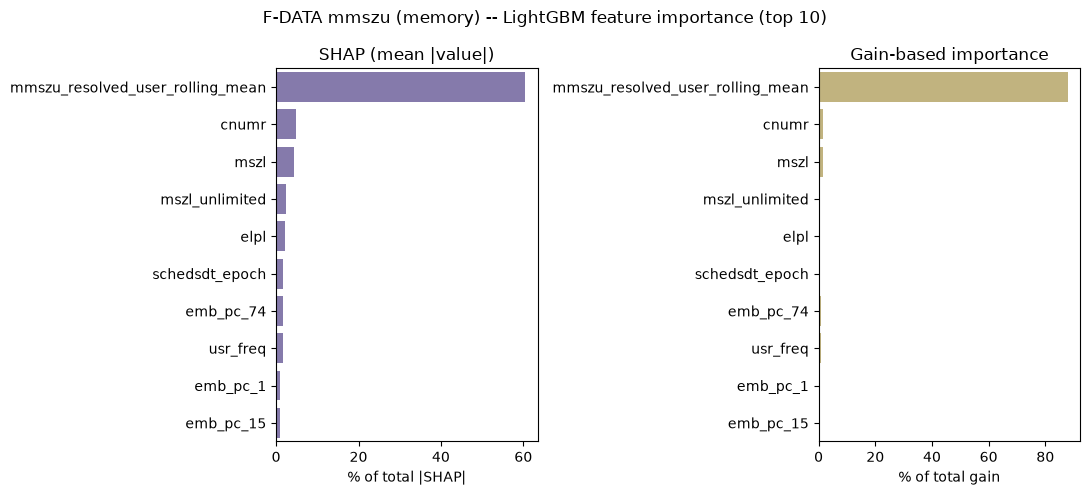

In [22]:
import shap

def gain_importance_for(model, model_name, columns):
    if model_name == "LightGBM":
        return pd.Series(model.booster_.feature_importance(importance_type="gain"), index=columns)
    if model_name == "XGBoost":
        return pd.Series(model.get_booster().get_score(importance_type="gain")).reindex(columns).fillna(0.0)
    if model_name == "RandomForest":
        return pd.Series(model.feature_importances_, index=columns)
    raise ValueError(model_name)

gain_importance = gain_importance_for(best_model, best_model_name, X_train.columns)

_shap_n = min(SHAP_SAMPLE, len(X_test))
_si = np.random.RandomState(SEED).permutation(len(X_test))[:_shap_n]
X_shap = X_test.iloc[_si]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns)
print(f"SHAP computed on {_shap_n:,} of {len(X_test):,} test rows ({best_model_name})")

fig = plotting.plot_feature_importance_comparison(
    gain_importance, shap_importance,
    f"F-DATA mmszu (memory) -- {best_model_name} feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "fdata_memory_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15g: metrics heatmap

No analytical reference row exists for memory -- only Naive is excluded from the scale (it would otherwise flatten the colours of the three real models, same reasoning as every other heatmap in this project).

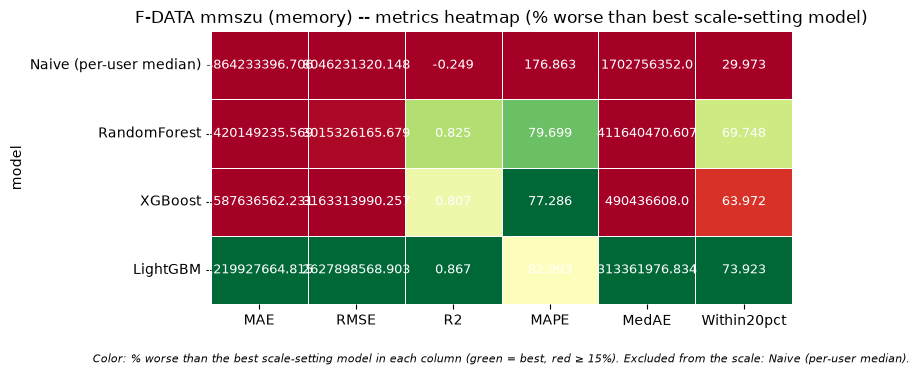

In [23]:
fig = plotting.plot_metrics_heatmap(
    summary_df,
    "F-DATA mmszu (memory) -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"],
)
fig.savefig(FIGURES_DIR / "fdata_memory_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15h: absolute-error boxplot across models

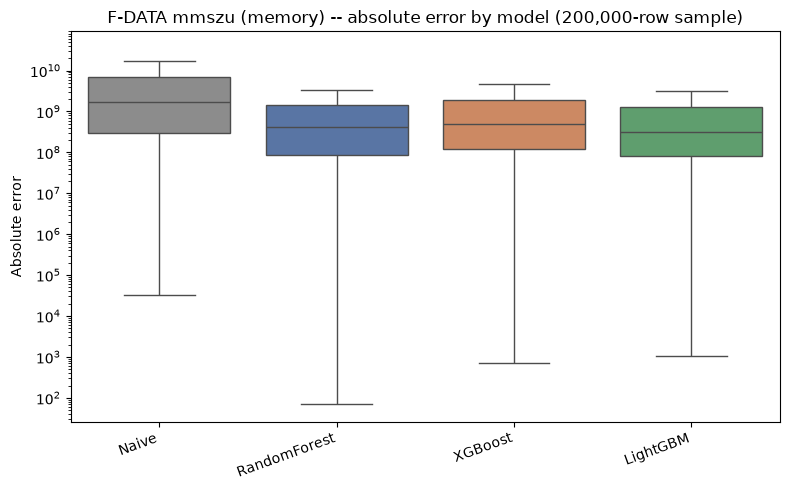

In [24]:
_box_preds = {
    "Naive": naive_pred[_pi],
    "RandomForest": features.inverse_transform_target(final_models["RandomForest"].predict(X_test.iloc[_pi])),
    "XGBoost": features.inverse_transform_target(final_models["XGBoost"].predict(X_test.iloc[_pi])),
    "LightGBM": features.inverse_transform_target(final_models["LightGBM"].predict(X_test.iloc[_pi])),
}
fig = plotting.plot_error_boxplot(
    y_test_raw[_pi], _box_preds,
    f"F-DATA mmszu (memory) -- absolute error by model ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_memory_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15i: feature correlation — final model-input matrix

Same pair as duration's Step 13g / notebook 02's Step 2b, on this notebook's actual `X_train` (emb_pc_* excluded, near-orthogonal by construction).

F-DATA correlation check on 13 non-embedding columns: ['cnumr', 'nnumr', 'elpl', 'mszl', 'pri', 'freq_req', 'mszl_unlimited', 'adt_epoch', 'qdt_epoch', 'schedsdt_epoch', 'jobenv_req_code', 'usr_freq', 'mmszu_resolved_user_rolling_mean']


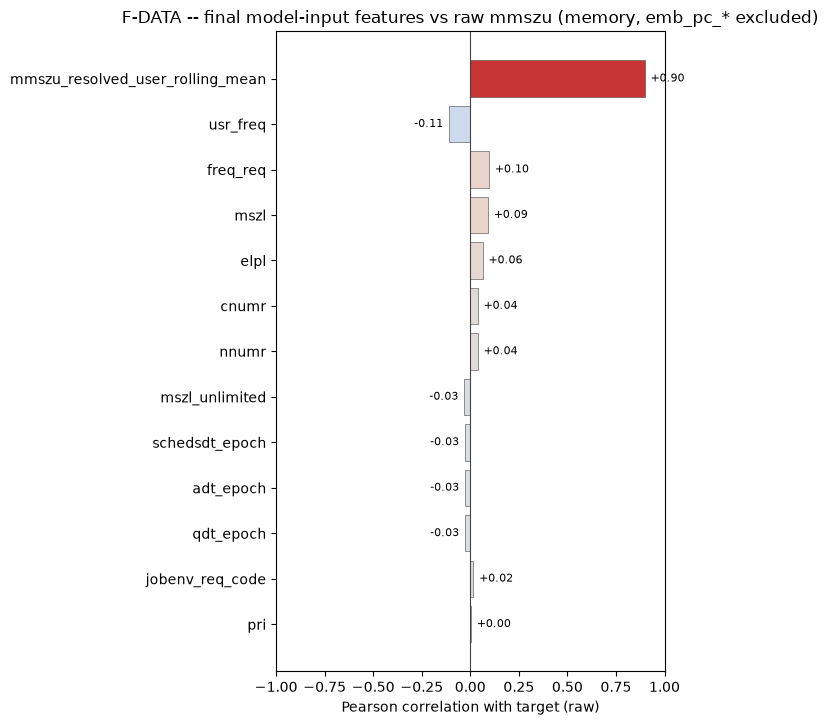

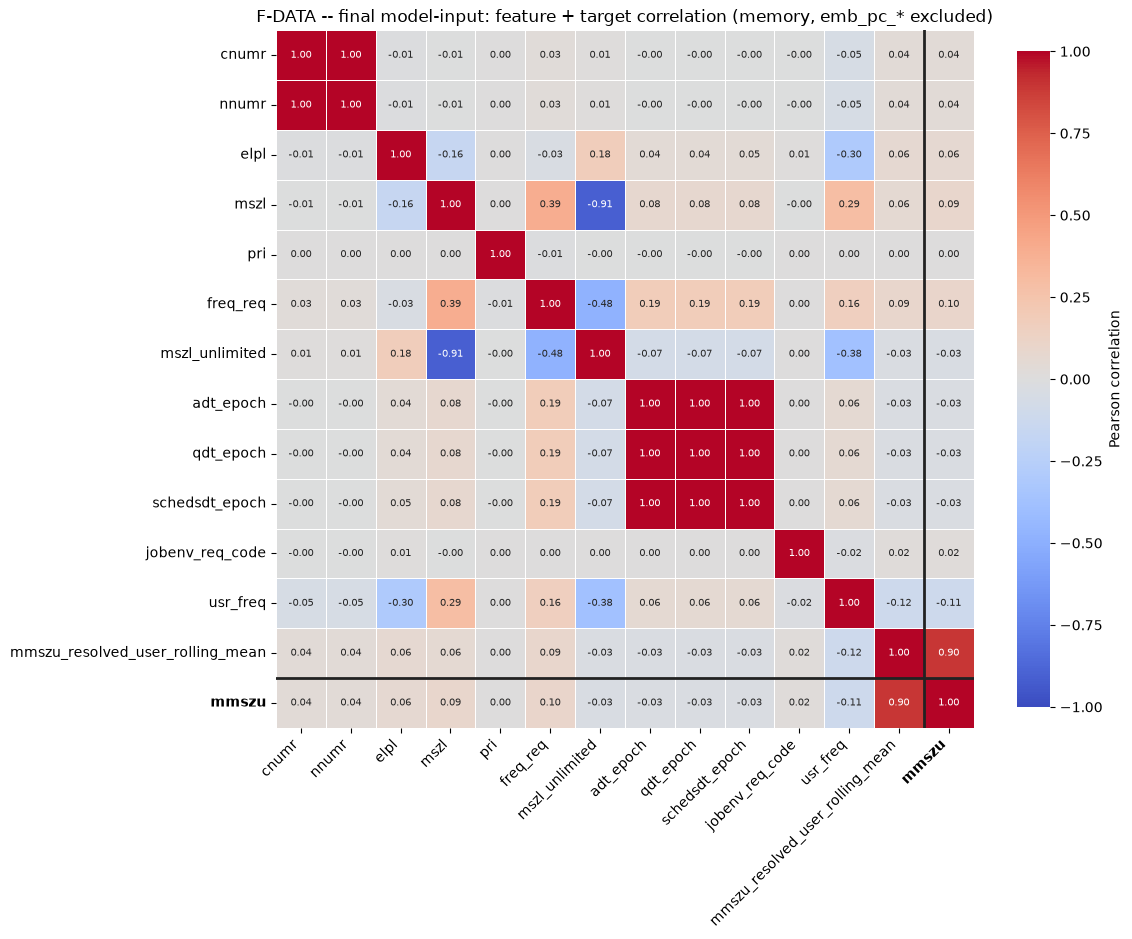

In [25]:
_xtrain_noemb = X_train[[c for c in X_train.columns if not c.startswith("emb_pc_")]]
print(f"F-DATA correlation check on {_xtrain_noemb.shape[1]} non-embedding columns: {list(_xtrain_noemb.columns)}")

fig = plotting.plot_feature_target_correlation(
    _xtrain_noemb, y_train_raw,
    "F-DATA -- final model-input features vs raw mmszu (memory, emb_pc_* excluded)")
fig.savefig(FIGURES_DIR / "fdata_memory_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    _xtrain_noemb,
    "F-DATA -- final model-input: feature + target correlation (memory, emb_pc_* excluded)",
    target=y_train_raw, target_name="mmszu")
fig.savefig(FIGURES_DIR / "fdata_memory_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Part 1 Summary

Pipeline executed: load all 38 F-DATA months -> exclude non-completed jobs -> `mszl` sentinel fix (inherited) -> resolve the `mmszu`/`msza` memory-target fallback (new, confirmed a no-op on this population) -> rolling-window decision tested at 5/20/50 (not assumed) -> chosen window's rolling-stat feature on the full timeline -> chronological split -> stratified tuning sample -> Tier A matrix + leakage re-check -> embedding PCA fit on the tuning sample -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline -> chronological tune/val carve-out -> **real 50-trial Optuna search per model family (no stored params to reuse)** -> single final fit per model (RandomForest capped at `RF_FINAL_FIT_CAP`), evaluated on the full test split.

**Deferred, not in scope for this pass:**
- F-DATA's `duration` and `power` (`avgpcon`) targets -- covered by notebook 05.
- Multi-seed repeats -- notebook 08's job.
- Re-tuning with a different rolling-window choice than the one selected in Step 4.

# Part 2: PM100 — Memory Target (`mem_alloc`)

**Executed in a separate, genuinely fresh kernel from Part 1** -- this Part is fully self-contained (its own imports, its own data load) by design, so it can run standalone. See the cell above Step 16 for why.

In [1]:
import sys
sys.path.append("..")

import glob
import time

import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from src import baselines, features, metrics, models, plotting, splits

optuna.logging.set_verbosity(optuna.logging.WARNING)

PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"
PM100_TARGET_COL = "mem_alloc"    # raw scalar column -- no reduction needed (unlike power)
PM100_TUNE_TRAIN_FRAC = 0.8
SHAP_SAMPLE = 200_000
N_TRIALS = models.TuningBudget().n_trials
SEED = 0

print(f"PM100_TARGET_COL={PM100_TARGET_COL}  N_TRIALS={N_TRIALS}")

/home/bizon/Documents/tobi/hpc-dl-enhanced/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PM100_TARGET_COL=mem_alloc  N_TRIALS=50


## Step 16: Load PM100 in full, exclude non-completed jobs

No sampling -- PM100's full dataset is small enough to use directly, same as every other PM100 target. `mem_alloc` is a plain scalar column (confirmed in the 05b planning report: `int64`, no per-job array reduction needed, unlike `node_power_consumption`).

In [2]:
pm100 = pd.read_parquet(PM100_PATH)
print(f"PM100 raw rows: {len(pm100):,}")

pm100 = features.filter_completed_jobs(pm100, "pm100")
print(f"rows after filtering: {len(pm100):,}")
print(f"mem_alloc null: {pm100['mem_alloc'].isna().sum():,}  dtype: {pm100['mem_alloc'].dtype}")

PM100 raw rows: 231,238
[pm100] excluded 22.0% of jobs as non-completed (50928 / 231238)
rows after filtering: 180,310
mem_alloc null: 0  dtype: int64


## Step 17: Feature Vetting derived indicators

`add_pm100_derived_indicators` must run before `build_tier_a_features` (`num_tasks_missing` is derived, not a raw column) -- same ordering requirement as every PM100 target, inherited infrastructure, not memory-specific.

In [3]:
pm100 = features.add_pm100_derived_indicators(pm100)
features.assert_reserved_columns_preserved(pm100)
print("reserved columns preserved:", [c for c in features.PM100_RESERVED_COLUMNS if c in pm100.columns])

reserved columns preserved: ['req_nodes', 'threads_per_core', 'req_switch', 'node_pinned', 'threads_per_core_set', 'req_switch_set']


## Step 18: Rolling-stat window decision (Item 2) -- tested, not assumed

Same independent test as Part 1's Step 4: `window=5/20/50` rolling-mean-of-memory, correlated against the raw `mem_alloc` target.

In [4]:
_window_candidates = [5, 20, 50]
_window_results = {}
for _w in _window_candidates:
    _pr = features.add_user_rolling_stat(pm100, "pm100", PM100_TARGET_COL, window=_w)
    _col = f"{PM100_TARGET_COL}_user_rolling_mean"
    _cov = _pr[_col].notna().sum()
    _samp = _pr.dropna(subset=[_col, PM100_TARGET_COL])
    _corr = float(np.corrcoef(_samp[_col], _samp[PM100_TARGET_COL])[0, 1])
    _window_results[_w] = _corr
    print(f"  window={_w:3d}: coverage={_cov:,}/{len(_pr):,} ({_cov/len(_pr):.4%})  corr(rolling_mean, {PM100_TARGET_COL})={_corr:.4f}")
    del _pr, _samp

PM100_ROLLING_WINDOW = max(_window_results, key=_window_results.get)
print(f"\nchosen window: {PM100_ROLLING_WINDOW} (corr={_window_results[PM100_ROLLING_WINDOW]:.4f})")
print("Same direction as Part 1: correlation strictly decreases as the window widens. Also, per the "
      "05b planning report, this rolling feature (corr ~0.77) is weaker than num_nodes_req alone "
      "(corr ~0.89) -- unlike Part 1, the resource-request block is expected to matter more here "
      "than the historical feature; the stripped-feature ablation below quantifies this directly.")

  window=  5: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, mem_alloc)=0.7691


  window= 20: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, mem_alloc)=0.7013


  window= 50: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, mem_alloc)=0.6670

chosen window: 5 (corr=0.7691)
Same direction as Part 1: correlation strictly decreases as the window widens. Also, per the 05b planning report, this rolling feature (corr ~0.77) is weaker than num_nodes_req alone (corr ~0.89) -- unlike Part 1, the resource-request block is expected to matter more here than the historical feature; the stripped-feature ablation below quantifies this directly.


## Step 19: Build the chosen rolling-stat feature on the full timeline

In [5]:
pm100 = features.add_user_rolling_stat(pm100, "pm100", PM100_TARGET_COL, window=PM100_ROLLING_WINDOW)
pm100_rolling_col = f"{PM100_TARGET_COL}_user_rolling_mean"
print(f"rolling stat (window={PM100_ROLLING_WINDOW}) available for {pm100[pm100_rolling_col].notna().sum():,} / {len(pm100):,} jobs")

rolling stat (window=5) available for 179,883 / 180,310 jobs


## Step 20: Chronological split

No sampling follows -- PM100 is used in full on both sides, same as every other PM100 target.

In [6]:
pm100_train_df, pm100_test_df = splits.chronological_split(pm100, "pm100")
print(f"train={len(pm100_train_df):,} test={len(pm100_test_df):,} "
      f"(test/train ratio={len(pm100_test_df) / len(pm100_train_df):.4f})")

train=126,217 test=54,093 (test/train ratio=0.4286)


## Step 21: Tier A feature matrix + leakage re-check

In [7]:
pm100_train_tier_a = features.build_tier_a_features(pm100_train_df, "pm100")
pm100_test_tier_a = features.build_tier_a_features(pm100_test_df, "pm100")

features.assert_no_tier_leakage(list(pm100_train_tier_a.columns), "A", "pm100")
features.assert_no_tier_leakage(list(pm100_test_tier_a.columns), "A", "pm100")
print(f"PM100 Tier A: {len(pm100_train_tier_a.columns)} columns, OK")

PM100 Tier A: 16 columns, OK


## Step 22: Final numeric feature matrix + target transform

In [8]:
pm100_X_train = features.build_pm100_numeric_matrix(
    pm100_train_tier_a, extra_columns=pm100_train_df[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_test = features.build_pm100_numeric_matrix(
    pm100_test_tier_a, extra_columns=pm100_test_df[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_train_raw = pm100_train_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_test_raw = pm100_test_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_train = features.transform_target(pm100_y_train_raw)
pm100_y_test = features.transform_target(pm100_y_test_raw)

metrics.expm1_round_trip_check(pm100_y_train_raw)
metrics.expm1_round_trip_check(pm100_y_test_raw)

print(f"X_train shape: {pm100_X_train.shape}  X_test shape: {pm100_X_test.shape}")
print(f"feature columns: {list(pm100_X_train.columns)}")

X_train shape: (126217, 17)  X_test shape: (54093, 17)
feature columns: ['priority', 'time_limit', 'num_cores_req', 'num_nodes_req', 'num_gpus_req', 'mem_req', 'cores_per_task', 'num_tasks', 'num_tasks_missing', 'submit_time_epoch', 'eligible_time_epoch', 'partition_code', 'qos_code', 'shared_code', 'group_id_code', 'user_id_freq', 'mem_alloc_user_rolling_mean']


## Step 23: Naive per-user-median baseline

In [9]:
pm100_user_medians, pm100_global_median = baselines.fit_naive_baseline(pm100_train_df, "pm100", PM100_TARGET_COL)
pm100_naive_pred = baselines.predict_naive_baseline(pm100_test_df, "pm100", pm100_user_medians, pm100_global_median)
pm100_naive_metrics = metrics.regression_metrics(pm100_y_test_raw, pm100_naive_pred)

print("Naive per-user-median baseline (PM100 mem_alloc, test split):")
for k, v in pm100_naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (PM100 mem_alloc, test split):
  MAE: 511.2822
  RMSE: 1,621.6866
  R2: 0.0768
  MAPE: 91.0715
  MedAE: 238.0000
  Within20pct: 31.5272


## Step 24: Chronological tuning/validation carve-out within train

In [10]:
pm100_tune_train_raw, pm100_tune_val_raw = splits.chronological_split(
    pm100_train_df, "pm100", train_frac=PM100_TUNE_TRAIN_FRAC
)
print(f"tune_train={len(pm100_tune_train_raw):,} tune_val={len(pm100_tune_val_raw):,}")

pm100_tune_train_tier_a = features.build_tier_a_features(pm100_tune_train_raw, "pm100")
pm100_tune_val_tier_a = features.build_tier_a_features(pm100_tune_val_raw, "pm100")

pm100_X_tune_train = features.build_pm100_numeric_matrix(
    pm100_tune_train_tier_a, extra_columns=pm100_tune_train_raw[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_tune_val = features.build_pm100_numeric_matrix(
    pm100_tune_val_tier_a, extra_columns=pm100_tune_val_raw[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_tune_train = features.transform_target(pm100_tune_train_raw[PM100_TARGET_COL].to_numpy(dtype=float))
pm100_y_tune_val = features.transform_target(pm100_tune_val_raw[PM100_TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {pm100_X_tune_train.shape}  X_tune_val shape: {pm100_X_tune_val.shape}")

tune_train=100,973 tune_val=25,244


X_tune_train shape: (100973, 17)  X_tune_val shape: (25244, 17)


## Step 25: Optuna hyperparameter search — RF / XGBoost / LightGBM

**Real search, no `SKIP_TUNING_PM100`.** This cell's tuning times are the direct test of the thread-contention hypothesis from PM100 power's tuning-cost investigation: run here in a genuinely fresh kernel, not chained after Part 1's multi-hour F-DATA tuning, so any inflation this time can't be blamed on carried-over thread-pool state.

In [11]:
def pm100_rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 250),
        max_depth=trial.suggest_int("max_depth", 4, 18),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
    )
    model = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


def pm100_xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = XGBRegressor(**params, tree_method="hist", n_jobs=-1, random_state=SEED)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


def pm100_lgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = LGBMRegressor(**params, bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


pm100_objectives = {
    "RandomForest": pm100_rf_objective, "XGBoost": pm100_xgb_objective, "LightGBM": pm100_lgbm_objective,
}
pm100_best_params = {}
pm100_tuning_seconds = {}

for name, objective in pm100_objectives.items():
    start = time.perf_counter()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    pm100_tuning_seconds[name] = time.perf_counter() - start
    pm100_best_params[name] = study.best_params
    print(f"{name}: best RMSE(log-space)={study.best_value:.4f}  "
          f"tuning time={pm100_tuning_seconds[name]:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={study.best_params}")

print("\n" + "=" * 70)
print("FRESH-KERNEL TUNING VERDICT (thread-contention hypothesis test)")
print("=" * 70)
print("Pre-migration (2026-08-16, old workstation):        RF=87.6s   XGB=26.0s    LGBM=48.6s")
print("Chained-after-8h (2026-08-28, ed49f06, same kernel as F-DATA): RF=71.9s   XGB=454.9s   LGBM=1132.2s")
print(f"This run (fresh kernel, isolated, no prior F-DATA tuning):     "
      f"RF={pm100_tuning_seconds['RandomForest']:.1f}s   "
      f"XGB={pm100_tuning_seconds['XGBoost']:.1f}s   LGBM={pm100_tuning_seconds['LightGBM']:.1f}s")

RandomForest: best RMSE(log-space)=0.0628  tuning time=77.0s  n_trials=50
    best_params={'n_estimators': 125, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 0.964286724517838}


XGBoost: best RMSE(log-space)=0.0567  tuning time=60.8s  n_trials=50
    best_params={'n_estimators': 315, 'max_depth': 8, 'learning_rate': 0.03905453391570842, 'subsample': 0.7294795269246798, 'colsample_bytree': 0.9220601400732221}


LightGBM: best RMSE(log-space)=0.0644  tuning time=122.0s  n_trials=50
    best_params={'n_estimators': 276, 'num_leaves': 178, 'learning_rate': 0.04093944822901454, 'subsample': 0.8011088010679889, 'colsample_bytree': 0.9346648837730069}

FRESH-KERNEL TUNING VERDICT (thread-contention hypothesis test)
Pre-migration (2026-08-16, old workstation):        RF=87.6s   XGB=26.0s    LGBM=48.6s
Chained-after-8h (2026-08-28, ed49f06, same kernel as F-DATA): RF=71.9s   XGB=454.9s   LGBM=1132.2s
This run (fresh kernel, isolated, no prior F-DATA tuning):     RF=77.0s   XGB=60.8s   LGBM=122.0s


## Step 26: Final fit on the full PM100 train split, evaluate on test

In [12]:
pm100_final_models = {
    "RandomForest": RandomForestRegressor(**pm100_best_params["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**pm100_best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**pm100_best_params["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}

pm100_fit_seconds = {}
pm100_results = {}
for name, model in pm100_final_models.items():
    start = time.perf_counter()
    model.fit(pm100_X_train, pm100_y_train)
    pm100_fit_seconds[name] = time.perf_counter() - start
    pred_log = model.predict(pm100_X_test)
    pred_raw = features.inverse_transform_target(pred_log)
    pm100_results[name] = {
        "log_space": metrics.regression_metrics(pm100_y_test, pred_log),
        "raw_space": metrics.regression_metrics(pm100_y_test_raw, pred_raw),
    }
    print(f"{name}: final fit time={pm100_fit_seconds[name]:.1f}s")

RandomForest: final fit time=2.1s


XGBoost: final fit time=1.1s


LightGBM: final fit time=3.2s


## Step 27: Results — PM100 `mem_alloc` (memory) target

No analytical reference row -- same confirmation as Part 1, no memory-target formula exists for PM100 in `src/roofline.py` either.

In [13]:
print("=" * 70)
print(f"RESULTS -- PM100 {PM100_TARGET_COL} target, test split (n={len(pm100_test_df):,})")
print("=" * 70)

pm100_summary_rows = [{"model": "Naive (per-user median)", **pm100_naive_metrics}]
for name in pm100_final_models:
    pm100_summary_rows.append({"model": name, **pm100_results[name]["raw_space"]})
pm100_summary_df = pd.DataFrame(pm100_summary_rows).set_index("model")

print("\nRaw-space metrics, full PM100 dataset (no sampling):")
display(pm100_summary_df.round(4))

pm100_log_df = pd.DataFrame([{"model": n, **pm100_results[n]["log_space"]} for n in pm100_final_models]).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(pm100_log_df.round(4))

pm100_best_model_name = pm100_summary_df.drop(index="Naive (per-user median)")["R2"].idxmax()
print(f"\nBest model by R2: {pm100_best_model_name} (R2={pm100_summary_df.loc[pm100_best_model_name, 'R2']:.4f})")

print(f"\nOptuna tuning time per model family (N_TRIALS={N_TRIALS} each) -- see the fresh-kernel "
      f"verdict printed in Step 25:")
for name in pm100_final_models:
    print(f"  {name}: tuning={pm100_tuning_seconds[name]:.1f}s  final_fit={pm100_fit_seconds[name]:.1f}s")

RESULTS -- PM100 mem_alloc target, test split (n=54,093)

Raw-space metrics, full PM100 dataset (no sampling):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),511.2822,1621.6866,0.0768,91.0715,238.0000,31.5272
RandomForest,9.9222,254.2546,0.9773,1.8716,0.0000,98.5839
XGBoost,29.7576,331.7707,0.9614,3.5850,2.3361,93.3023
LightGBM,31.9018,209.8636,0.9845,7.8986,23.4651,98.1865



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.0206,0.1065,0.9904,0.4060,0.0000,99.8503
XGBoost,0.0370,0.1013,0.9913,0.7205,0.0099,99.9002
LightGBM,0.0763,0.1075,0.9902,1.4325,0.0940,99.8484



Best model by R2: LightGBM (R2=0.9845)

Optuna tuning time per model family (N_TRIALS=50 each) -- see the fresh-kernel verdict printed in Step 25:
  RandomForest: tuning=77.0s  final_fit=2.1s
  XGBoost: tuning=60.8s  final_fit=1.1s
  LightGBM: tuning=122.0s  final_fit=3.2s


### Step 27b: Predicted vs. actual — best model

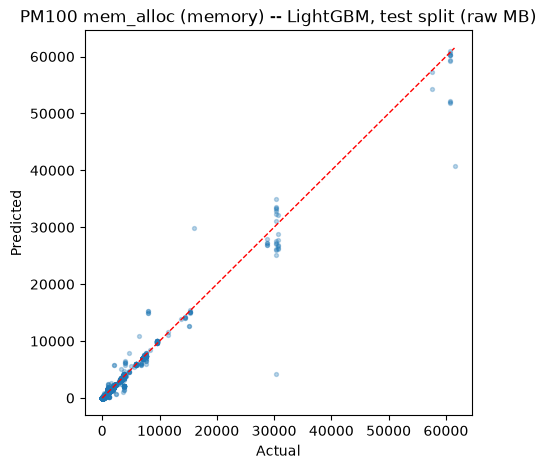

In [14]:
import pathlib
import matplotlib.pyplot as plt

FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

pm100_best_model = pm100_final_models[pm100_best_model_name]
pm100_best_pred_raw = features.inverse_transform_target(pm100_best_model.predict(pm100_X_test))

fig = plotting.plot_predicted_vs_actual(
    pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 mem_alloc (memory) -- {pm100_best_model_name}, test split (raw MB)"
)
fig.savefig(FIGURES_DIR / "pm100_memory_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27c: residuals

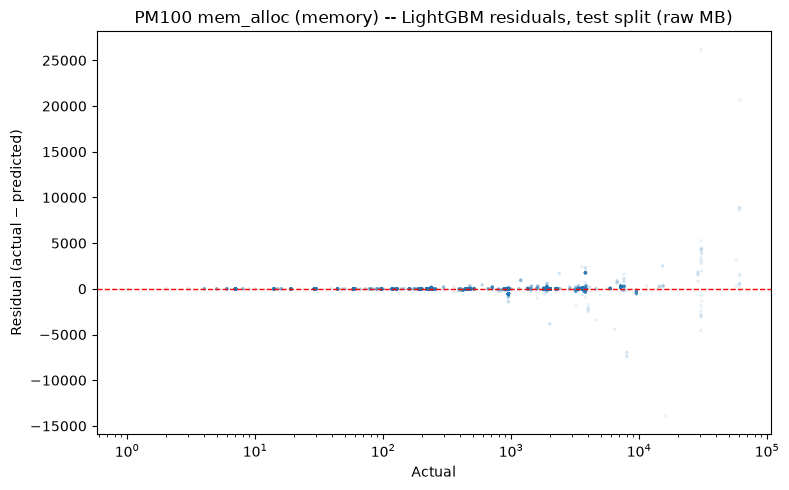

In [15]:
fig = plotting.plot_residuals(
    pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 mem_alloc (memory) -- {pm100_best_model_name} residuals, test split (raw MB)"
)
fig.savefig(FIGURES_DIR / "pm100_memory_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27d: absolute error by job-size bucket (num_cores_req)

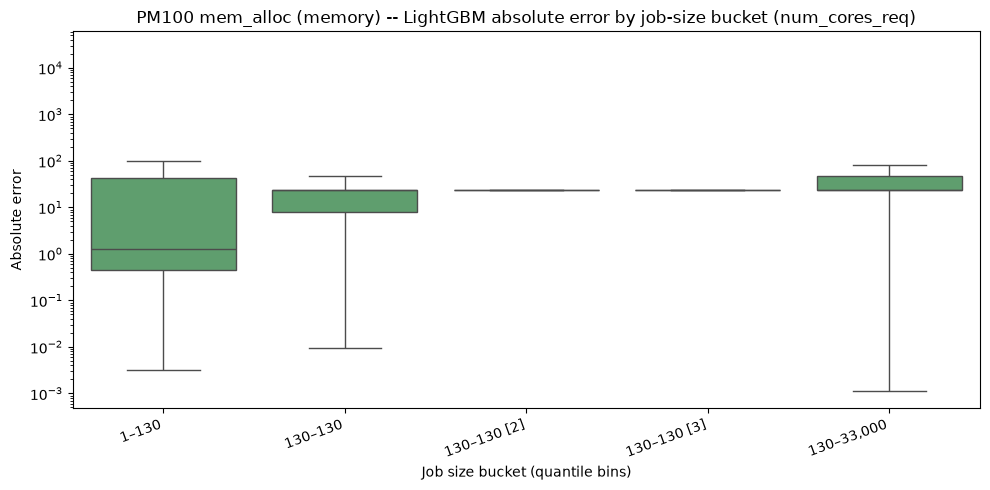

In [16]:
fig = plotting.plot_error_by_size_bucket(
    pm100_test_df["num_cores_req"].to_numpy(), pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 mem_alloc (memory) -- {pm100_best_model_name} absolute error by job-size bucket (num_cores_req)",
    n_buckets=5, model=pm100_best_model_name,
)
fig.savefig(FIGURES_DIR / "pm100_memory_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27e: metrics heatmap

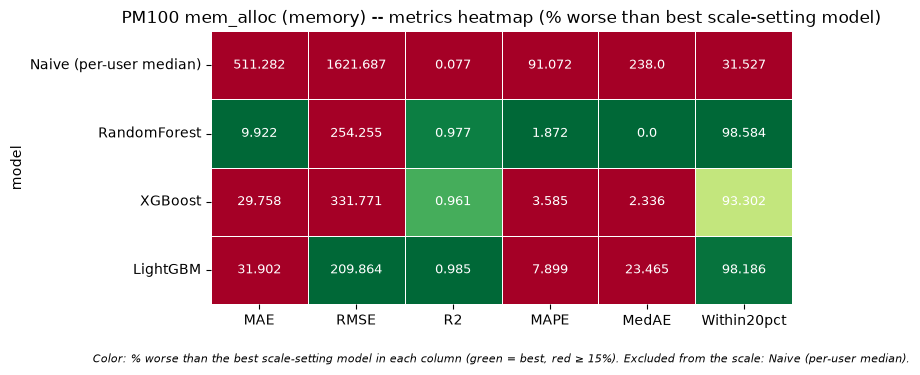

In [17]:
fig = plotting.plot_metrics_heatmap(
    pm100_summary_df,
    "PM100 mem_alloc (memory) -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"],
)
fig.savefig(FIGURES_DIR / "pm100_memory_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27f: absolute-error boxplot across models

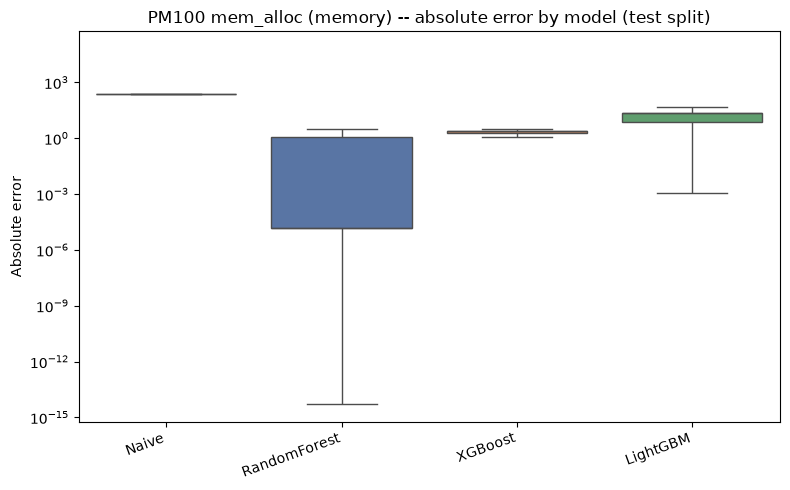

In [18]:
_pm100_box_preds = {
    "Naive": pm100_naive_pred,
    "RandomForest": features.inverse_transform_target(pm100_final_models["RandomForest"].predict(pm100_X_test)),
    "XGBoost": features.inverse_transform_target(pm100_final_models["XGBoost"].predict(pm100_X_test)),
    "LightGBM": features.inverse_transform_target(pm100_final_models["LightGBM"].predict(pm100_X_test)),
}
fig = plotting.plot_error_boxplot(
    pm100_y_test_raw, _pm100_box_preds, "PM100 mem_alloc (memory) -- absolute error by model (test split)"
)
fig.savefig(FIGURES_DIR / "pm100_memory_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27g: Model comparison — R² vs. MAPE

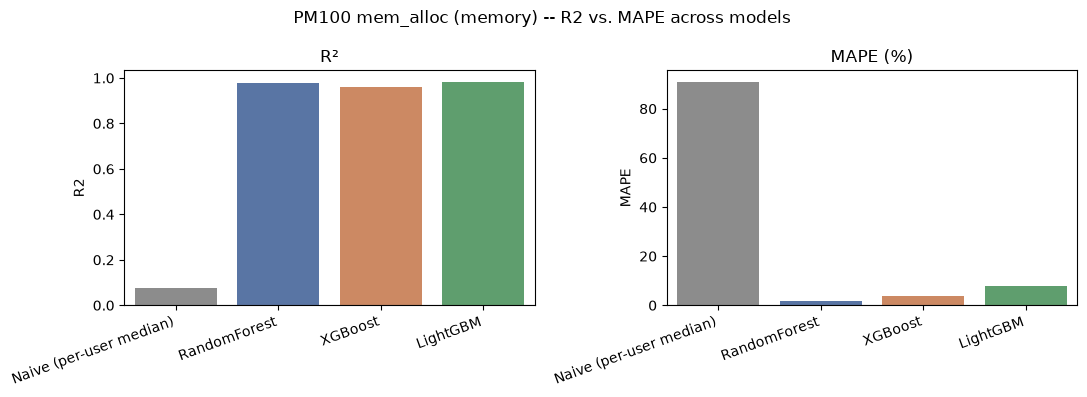

In [19]:
fig = plotting.plot_model_comparison(pm100_summary_df, "PM100 mem_alloc (memory) -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "pm100_memory_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27h: Feature importance — best model, gain vs. SHAP

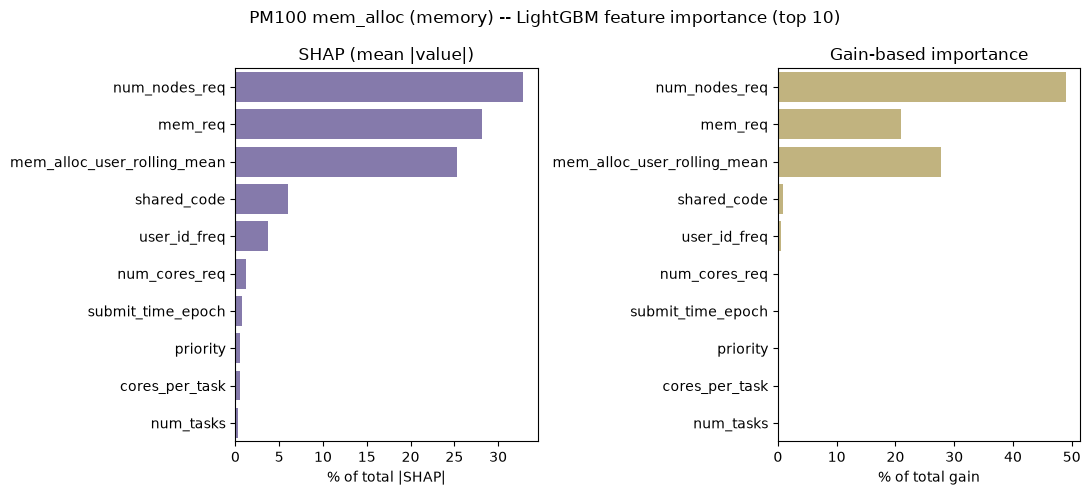

In [20]:
import shap

def gain_importance_for(model, model_name, columns):
    if model_name == "LightGBM":
        return pd.Series(model.booster_.feature_importance(importance_type="gain"), index=columns)
    if model_name == "XGBoost":
        return pd.Series(model.get_booster().get_score(importance_type="gain")).reindex(columns).fillna(0.0)
    if model_name == "RandomForest":
        return pd.Series(model.feature_importances_, index=columns)
    raise ValueError(model_name)

pm100_gain_importance = gain_importance_for(pm100_best_model, pm100_best_model_name, pm100_X_train.columns)

pm100_explainer = shap.TreeExplainer(pm100_best_model)
pm100_shap_values = pm100_explainer.shap_values(pm100_X_test)
pm100_shap_importance = pd.Series(np.abs(pm100_shap_values).mean(axis=0), index=pm100_X_train.columns)

fig = plotting.plot_feature_importance_comparison(
    pm100_gain_importance, pm100_shap_importance,
    f"PM100 mem_alloc (memory) -- {pm100_best_model_name} feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "pm100_memory_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27i: feature correlation — final model-input matrix

PM100 correlation check on 17 columns: ['priority', 'time_limit', 'num_cores_req', 'num_nodes_req', 'num_gpus_req', 'mem_req', 'cores_per_task', 'num_tasks', 'num_tasks_missing', 'submit_time_epoch', 'eligible_time_epoch', 'partition_code', 'qos_code', 'shared_code', 'group_id_code', 'user_id_freq', 'mem_alloc_user_rolling_mean']


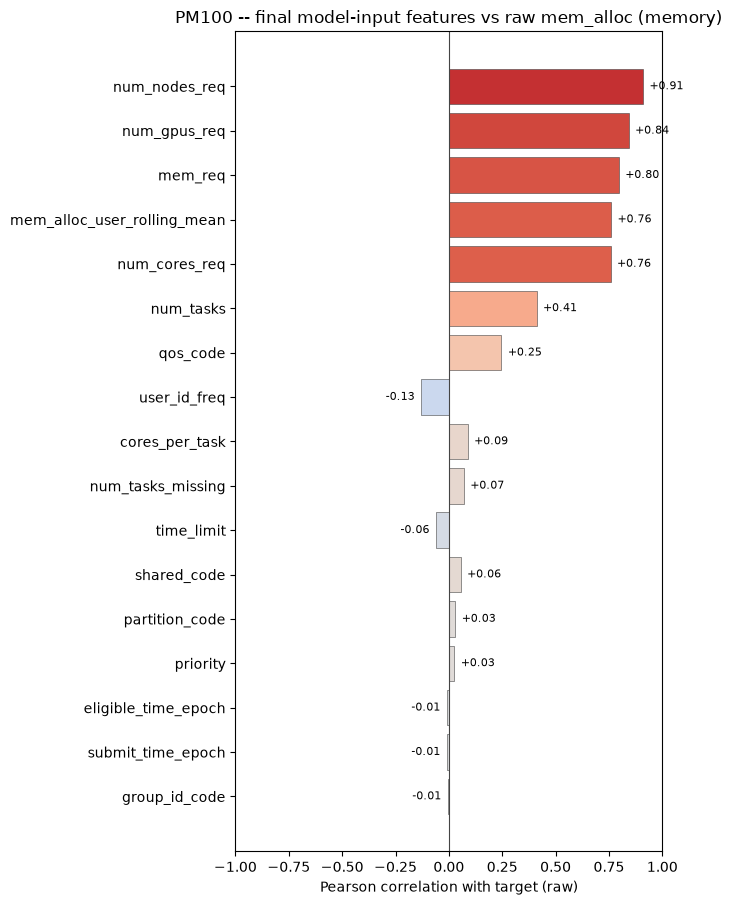

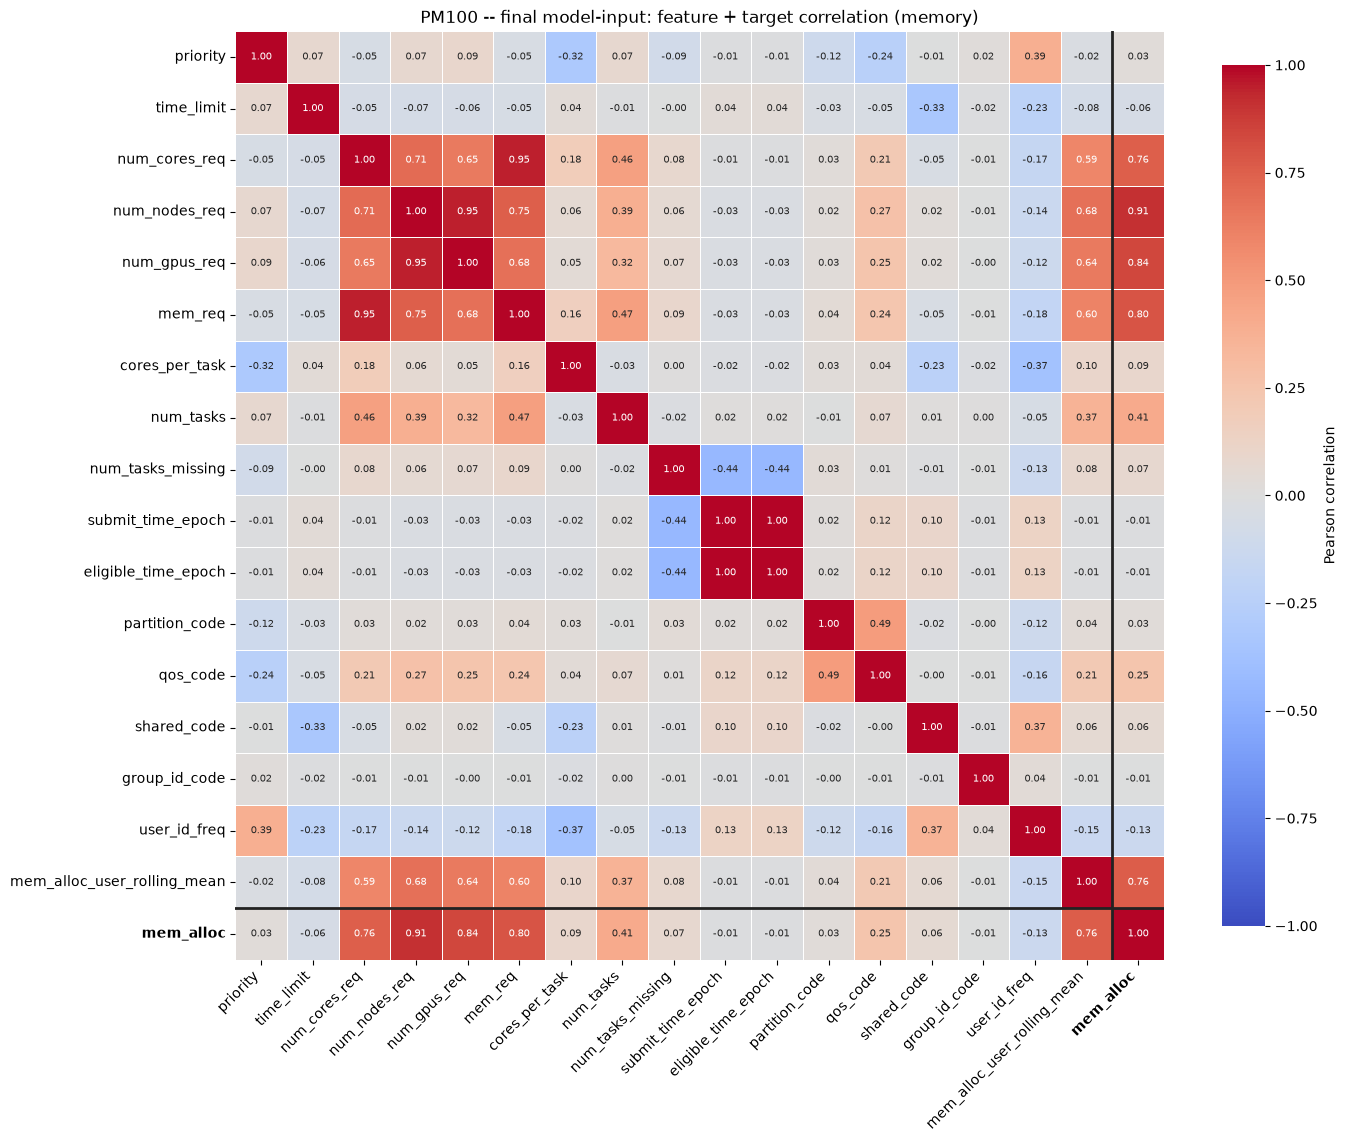

In [21]:
print(f"PM100 correlation check on {pm100_X_train.shape[1]} columns: {list(pm100_X_train.columns)}")

fig = plotting.plot_feature_target_correlation(
    pm100_X_train, pm100_y_train_raw,
    "PM100 -- final model-input features vs raw mem_alloc (memory)")
fig.savefig(FIGURES_DIR / "pm100_memory_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    pm100_X_train,
    "PM100 -- final model-input: feature + target correlation (memory)",
    target=pm100_y_train_raw, target_name="mem_alloc")
fig.savefig(FIGURES_DIR / "pm100_memory_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Step 28: Stripped-feature ablation — does the resource-request block dominate?

Mirrors PM100 power's stripped-feature ablation exactly: refit XGBoost using *only* the four Tier A resource-request fields (`num_cores_req`, `num_nodes_req`, `num_gpus_req`, `mem_req`) -- no categoricals, no `user_id_freq`, no rolling-stat -- to quantify Item 2's finding that the request block (num_nodes_req corr ~0.89) likely dominates over the rolling-stat feature (corr ~0.77) for memory, rather than assume it.

**Caveat unique to this ablation, unlike power's**: one of the four stripped fields, `mem_req` (memory *requested*), is unusually close to the target itself, `mem_alloc` (memory *allocated*) -- these are the same quantity at two points in the scheduling pipeline, not independent information the way `num_cores_req` is independent of `power_mean`. A strong score here is expected for that reason alone, not necessarily evidence the other 3 fields carry much weight -- interpret accordingly.

In [22]:
_stripped_cols = ["num_cores_req", "num_nodes_req", "num_gpus_req", "mem_req"]
pm100_X_train_stripped = pm100_train_tier_a[_stripped_cols].astype(float)
pm100_X_test_stripped = pm100_test_tier_a[_stripped_cols].astype(float)

_stripped_model = XGBRegressor(**pm100_best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED)
_stripped_model.fit(pm100_X_train_stripped, pm100_y_train)
_stripped_pred_raw = features.inverse_transform_target(_stripped_model.predict(pm100_X_test_stripped))
_stripped_metrics = metrics.regression_metrics(pm100_y_test_raw, _stripped_pred_raw)

print(f"Stripped-feature XGBoost (4 resource-request fields only) vs full-feature "
      f"({pm100_X_train.shape[1]} cols) XGBoost, PM100 mem_alloc:")
_ablation_df = pd.DataFrame([
    {"model": "XGBoost (stripped, 4 fields)", **_stripped_metrics},
    {"model": "XGBoost (full features)", **pm100_results["XGBoost"]["raw_space"]},
]).set_index("model")
display(_ablation_df.round(4))

Stripped-feature XGBoost (4 resource-request fields only) vs full-feature (17 cols) XGBoost, PM100 mem_alloc:


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
"XGBoost (stripped, 4 fields)",46.8937,564.0520,0.8883,18.9003,0.0731,97.4488
XGBoost (full features),29.7576,331.7707,0.9614,3.5850,2.3361,93.3023


## Part 2 Summary

Pipeline executed: load PM100 in full -> exclude non-completed jobs -> Feature Vetting derived indicators -> rolling-window decision tested at 5/20/50 (not assumed) -> chosen window's rolling-stat feature -> chronological split (no sampling) -> Tier A matrix + leakage re-check -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline -> chronological tune/val carve-out -> **real 50-trial Optuna search per model family, in a genuinely fresh kernel separate from Part 1** -> single final fit per model, evaluated on the held-out test split -> stripped-feature ablation.

**Deferred, not in scope for this pass:**
- PM100's `execution_time` (`run_time`) and `power` (`power_mean`) targets -- power is notebook 05; execution_time remains fully deferred.
- Multi-seed repeats -- notebook 08's job.
- Re-tuning with a different rolling-window choice than the one selected in Step 18.

## Part 2c: Result 2 — Clean 4-feature set (`mem_req` dropped)

**This section is additive.** Everything above — the full 17-feature tuning, fitting, results (Step 27), stripped ablation (Step 28), and all `pm100_memory_*.png` figures — is left exactly as it was produced and stays as the *investigated-and-rejected* record. This section adopts a smaller feature set for all three models and documents why.

### The decision

`mem_req` (memory requested) was dropped after a direct investigation showed it **equals `mem_alloc` exactly on 93.76% of test jobs** (correlation 0.8401; on the 6.24% of divergent rows the allocation is *always* larger than the request, median +230 MB, heavy tail to +58,900 MB). With `mem_req` in the matrix, every model substitutes a lookup for learning on the tautological majority and then fails on exactly the ~6.24% of jobs where request and allocation diverge — the cases that genuine submission-time memory prediction is actually *for*. A trivial "predict `mem_req`" model already scores R² 0.7047 / MedAE 0.00 on its own, so a large part of the full-17 headline (R² 0.96–0.98, MedAE ≈ 0, Within20 ≈ 98%) is mechanical, not learned.

The replacement is the historical feature `mem_alloc_user_rolling_mean` (each user's mean prior-job allocation, strictly-past via `shift(1)` — a legitimate submission-time signal, not a target leak).

### Full-17 (with `mem_req`) vs. clean-4 (without) — tested per model, not assumed

Full-17 numbers are the committed Step 27 results; clean-4 numbers come from real per-model 50-trial Optuna re-tunes on this exact 4-column set (reproduced in Step 31 below).

| Model | Feature set | subset | R² | MAPE | MedAE | Within20% |
|---|---|---|---|---|---|---|
| **RandomForest** | full-17 (`+mem_req`) | ALL | 0.9773 | 1.87% | 0.00 | 98.6% |
| | | divergent | 0.9798 | 19.33% | 35.70 | 85.2% |
| | **clean-4** | ALL | 0.9509 | 5.75% | 0.83 | 97.4% |
| | | divergent | 0.9536 | 20.89% | **0.73** | **93.6%** |
| **XGBoost** | full-17 (`+mem_req`) | ALL | 0.9614 | 3.58% | 2.34 | 93.3% |
| | | divergent | 0.9590 | 26.09% | 69.12 | **17.9%** |
| | **clean-4** | ALL | 0.9658 | 6.70% | 0.08 | 97.4% |
| | | divergent | 0.9591 | 26.01% | **0.73** | **92.3%** |
| **LightGBM** | full-17 (`+mem_req`) | ALL | 0.9845 | 7.90% | 23.47 | 98.2% |
| | | divergent | 0.9768 | 18.67% | 44.09 | 83.2% |
| | **clean-4** | ALL | 0.9599 | 6.03% | 0.07 | 97.4% |
| | | divergent | 0.9465 | 25.09% | **0.23** | **92.1%** |

The `mem_req` "helps the easy majority, hurts the hard minority" pattern replicated identically for all three models in the minimal-4 comparison (contaminated-4 divergent R² ≈ 0.72–0.75 vs clean-4 divergent R² ≈ 0.95–0.96).

### Per-model verdict

- **XGBoost — unambiguous.** Full-17 collapses on divergent-row accuracy (Within20% **17.9%**, MedAE 69). Clean-4 fixes it (Within20% 92.3%, MedAE 0.73) at no real R² cost. Clean-4 adopted.
- **RandomForest and LightGBM — a genuine tradeoff.** Full-17 gives higher aggregate R² (RF 0.977, LGBM 0.985) *and* higher divergent-subset R², because with 16 other features present these two can lean elsewhere for the hard rows. But their divergent-row *point* accuracy is still far worse than clean-4 (RF MedAE 35.7 vs 0.73; LGBM MedAE 44.1 vs 0.23). **Clean-4 was chosen deliberately** — prioritising honest, reliable performance on the ~6% of jobs where request ≠ allocation over a higher but partly-mechanical aggregate score.

Same 4-feature set for all three models: `num_nodes_req`, `num_gpus_req`, `num_cores_req`, `mem_alloc_user_rolling_mean`. `best_params` below are from the completed per-model re-tunes — no Optuna re-run here.

### Step 29: build the clean 4-feature matrices

Reuses `pm100_train_df` / `pm100_test_df` / `pm100_rolling_col` from Part 2 above (same chronological split, same rolling-stat column). Every other column from the 17-feature production matrix is dropped, including `mem_req`.

In [23]:
CLEAN4_COLS = ["num_nodes_req", "num_gpus_req", "num_cores_req", pm100_rolling_col]
pm100_X_train_c4 = pm100_train_df[CLEAN4_COLS].astype(float).fillna(0.0)
pm100_X_test_c4 = pm100_test_df[CLEAN4_COLS].astype(float).fillna(0.0)
print(f"clean-4 matrix: X_train {pm100_X_train_c4.shape}  X_test {pm100_X_test_c4.shape}")
print(f"columns: {list(pm100_X_train_c4.columns)}")

clean-4 matrix: X_train (126217, 4)  X_test (54093, 4)
columns: ['num_nodes_req', 'num_gpus_req', 'num_cores_req', 'mem_alloc_user_rolling_mean']


### Step 30: fit the three models at their re-tuned 4-feature `best_params` (no re-tuning)

`best_params` are from real 50-trial Optuna searches run on this exact 4-column set (same search space / sampler seed / chronological tune-val carve-out as Part 2's Step 25). No Optuna is run in this cell.

In [24]:
_C4_BEST_PARAMS = {
    "RandomForest": {"n_estimators": 149, "max_depth": 10, "min_samples_leaf": 5, "max_features": 0.9286795150728064},
    "XGBoost": {"n_estimators": 188, "max_depth": 11, "learning_rate": 0.030862925609952782, "subsample": 0.8768040541890576, "colsample_bytree": 0.8921051173321578},
    "LightGBM": {"n_estimators": 188, "num_leaves": 101, "learning_rate": 0.11965759404600158, "subsample": 0.8612368964975208, "colsample_bytree": 0.8312766647047717},
}
pm100_c4_models = {
    "RandomForest": RandomForestRegressor(**_C4_BEST_PARAMS["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**_C4_BEST_PARAMS["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**_C4_BEST_PARAMS["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}
pm100_c4_fit_seconds, pm100_c4_results = {}, {}
for name, model in pm100_c4_models.items():
    start = time.perf_counter()
    model.fit(pm100_X_train_c4, pm100_y_train)
    pm100_c4_fit_seconds[name] = time.perf_counter() - start
    pred_log = model.predict(pm100_X_test_c4)
    pred_raw = features.inverse_transform_target(pred_log)
    pm100_c4_results[name] = {
        "log_space": metrics.regression_metrics(pm100_y_test, pred_log),
        "raw_space": metrics.regression_metrics(pm100_y_test_raw, pred_raw),
    }
    print(f"{name}: fit {len(pm100_X_train_c4):,} rows in {pm100_c4_fit_seconds[name]:.1f}s")

RandomForest: fit 126,217 rows in 0.6s


XGBoost: fit 126,217 rows in 0.9s


LightGBM: fit 126,217 rows in 1.2s


### Step 31: Result 2 results table (clean 4-feature) + divergent-condition split

The divergent split (`mem_req == mem_alloc` vs not) is the decision criterion from the investigation, recomputed here on the freshly-fitted clean-4 models.

In [25]:
_div_same = (pm100_test_df["mem_req"].to_numpy(dtype=float) == pm100_y_test_raw)

print("=" * 74)
print(f"RESULT 2 -- PM100 mem_alloc, CLEAN 4-feature set (mem_req dropped), test n={len(pm100_test_df):,}")
print("=" * 74)

pm100_c4_summary_rows = [{"model": "Naive (per-user median)", **pm100_naive_metrics}]
for name in pm100_c4_models:
    pm100_c4_summary_rows.append({"model": name, **pm100_c4_results[name]["raw_space"]})
pm100_c4_summary_df = pd.DataFrame(pm100_c4_summary_rows).set_index("model")
print("\nRaw-space metrics (clean 4-feature), ALL test:")
display(pm100_c4_summary_df.round(4))

pm100_c4_log_df = pd.DataFrame(
    [{"model": n, **pm100_c4_results[n]["log_space"]} for n in pm100_c4_models]
).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(pm100_c4_log_df.round(4))

pm100_c4_best_name = pm100_c4_summary_df.drop(index="Naive (per-user median)")["R2"].idxmax()
print(f"\nBest clean-4 model by R2: {pm100_c4_best_name} "
      f"(R2={pm100_c4_summary_df.loc[pm100_c4_best_name, 'R2']:.4f})")
print(f"mem_req == mem_alloc on test: {_div_same.mean()*100:.2f}%  |  "
      f"divergent: {(~_div_same).sum():,} ({(~_div_same).mean()*100:.2f}%)")

_split_rows = []
for name, model in pm100_c4_models.items():
    pr = features.inverse_transform_target(model.predict(pm100_X_test_c4))
    for lbl, mask in [("ALL", np.ones(len(pr), bool)),
                      ("mem_req==mem_alloc", _div_same), ("divergent", ~_div_same)]:
        m = metrics.regression_metrics(pm100_y_test_raw[mask], pr[mask])
        _split_rows.append({"model": name, "subset": lbl, "R2": m["R2"], "MAPE": m["MAPE"],
                            "MedAE": m["MedAE"], "Within20pct": m["Within20pct"], "n": int(mask.sum())})
pm100_c4_split_df = pd.DataFrame(_split_rows).set_index(["model", "subset"])
print("\nClean 4-feature -- performance split by the divergent condition:")
display(pm100_c4_split_df.round(4))

RESULT 2 -- PM100 mem_alloc, CLEAN 4-feature set (mem_req dropped), test n=54,093

Raw-space metrics (clean 4-feature), ALL test:


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),511.2822,1621.6866,0.0768,91.0715,238.0000,31.5272
RandomForest,24.1213,374.0273,0.9509,5.7452,0.8276,97.4156
XGBoost,27.3610,312.0164,0.9658,6.7001,0.0820,97.4082
LightGBM,28.0444,337.8480,0.9599,6.0310,0.0721,97.4026



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.0274,0.1648,0.9770,0.6513,0.0035,99.3918
XGBoost,0.0295,0.1785,0.9730,0.7251,0.0003,99.2014
LightGBM,0.0271,0.1735,0.9745,0.6626,0.0003,99.2254



Best clean-4 model by R2: XGBoost (R2=0.9658)
mem_req == mem_alloc on test: 93.76%  |  divergent: 3,374 (6.24%)

Clean 4-feature -- performance split by the divergent condition:


R2     MAPE   MedAE  Within20pct      n
model        subset                                                         
RandomForest ALL                 0.9509   5.7452  0.8276      97.4156  54093
             mem_req==mem_alloc  0.9495   4.7377  0.8276      97.6675  50719
             divergent           0.9536  20.8902  0.7304      93.6277   3374
XGBoost      ALL                 0.9658   6.7001  0.0820      97.4082  54093
             mem_req==mem_alloc  0.9693   5.4154  0.0820      97.7464  50719
             divergent           0.9591  26.0115  0.7314      92.3237   3374
LightGBM     ALL                 0.9599   6.0310  0.0721      97.4026  54093
             mem_req==mem_alloc  0.9669   4.7633  0.0721      97.7523  50719
             divergent           0.9465  25.0870  0.2256      92.1458   3374

### Step 32: Result 2 diagnostic figures (clean 4-feature)

Same diagnostics as Part 2's Step 27b–i, regenerated for the adopted clean-4 models. Saved under `pm100_memory_clean4_*` so the full-17 figures are untouched. Uses the best clean-4 model by R2 for the per-model panels.

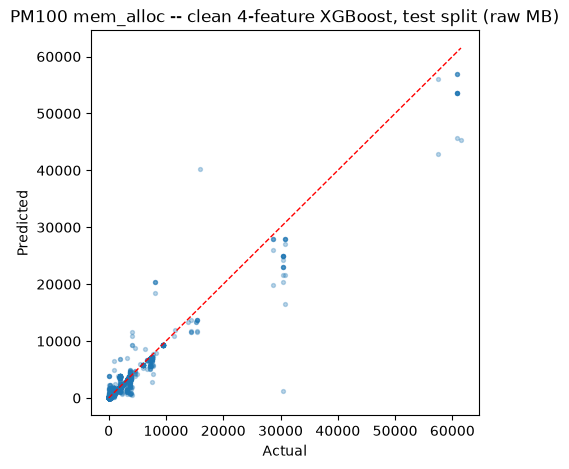

In [26]:
pm100_c4_best = pm100_c4_models[pm100_c4_best_name]
pm100_c4_best_pred_raw = features.inverse_transform_target(pm100_c4_best.predict(pm100_X_test_c4))

fig = plotting.plot_predicted_vs_actual(
    pm100_y_test_raw, pm100_c4_best_pred_raw,
    f"PM100 mem_alloc -- clean 4-feature {pm100_c4_best_name}, test split (raw MB)")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

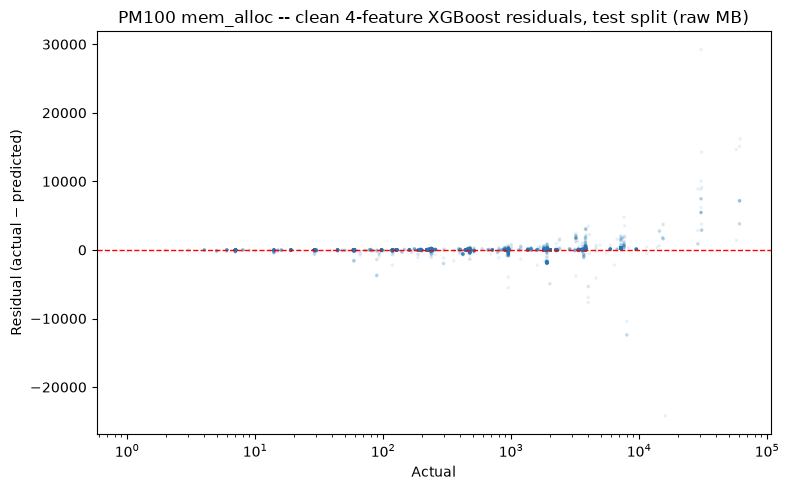

In [27]:
fig = plotting.plot_residuals(
    pm100_y_test_raw, pm100_c4_best_pred_raw,
    f"PM100 mem_alloc -- clean 4-feature {pm100_c4_best_name} residuals, test split (raw MB)")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

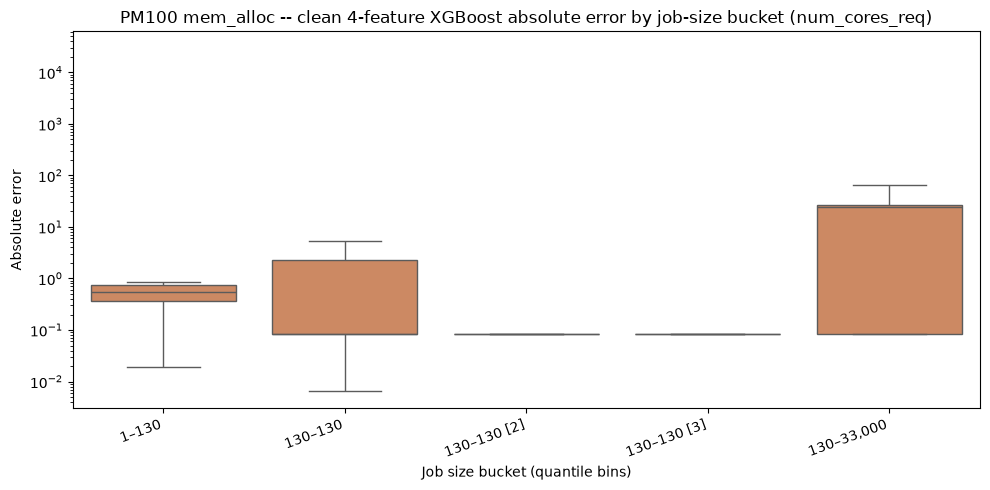

In [28]:
fig = plotting.plot_error_by_size_bucket(
    pm100_test_df["num_cores_req"].to_numpy(), pm100_y_test_raw, pm100_c4_best_pred_raw,
    f"PM100 mem_alloc -- clean 4-feature {pm100_c4_best_name} absolute error by job-size bucket (num_cores_req)",
    n_buckets=5, model=pm100_c4_best_name)
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

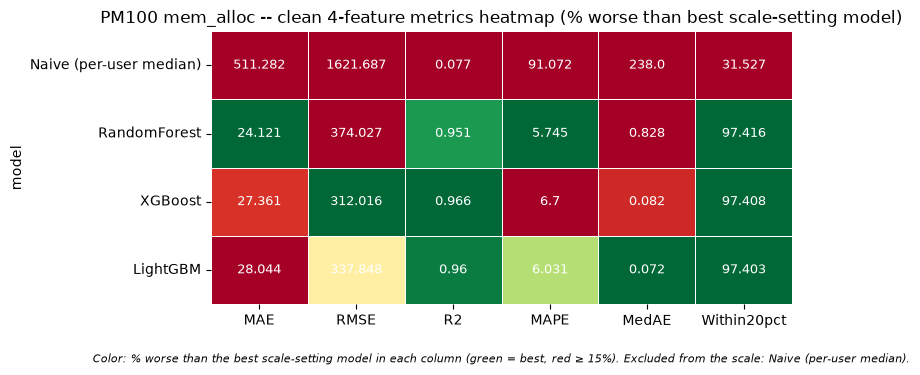

In [29]:
fig = plotting.plot_metrics_heatmap(
    pm100_c4_summary_df,
    "PM100 mem_alloc -- clean 4-feature metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"])
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

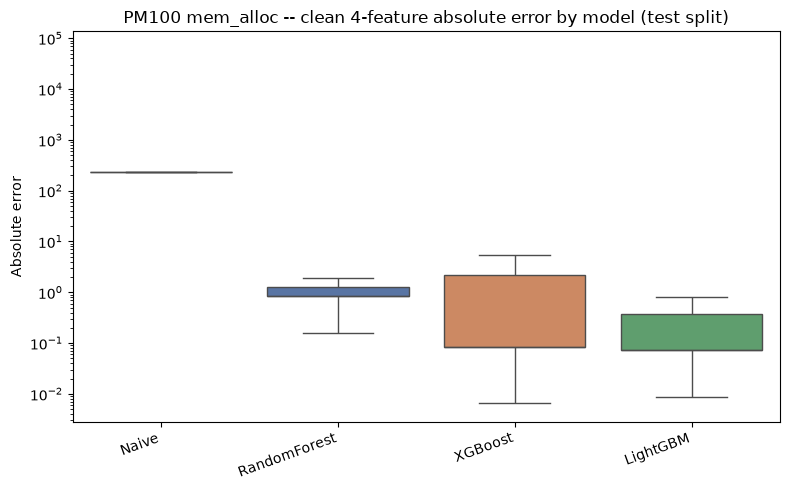

In [30]:
_c4_box_preds = {
    "Naive": pm100_naive_pred,
    "RandomForest": features.inverse_transform_target(pm100_c4_models["RandomForest"].predict(pm100_X_test_c4)),
    "XGBoost": features.inverse_transform_target(pm100_c4_models["XGBoost"].predict(pm100_X_test_c4)),
    "LightGBM": features.inverse_transform_target(pm100_c4_models["LightGBM"].predict(pm100_X_test_c4)),
}
fig = plotting.plot_error_boxplot(
    pm100_y_test_raw, _c4_box_preds, "PM100 mem_alloc -- clean 4-feature absolute error by model (test split)")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

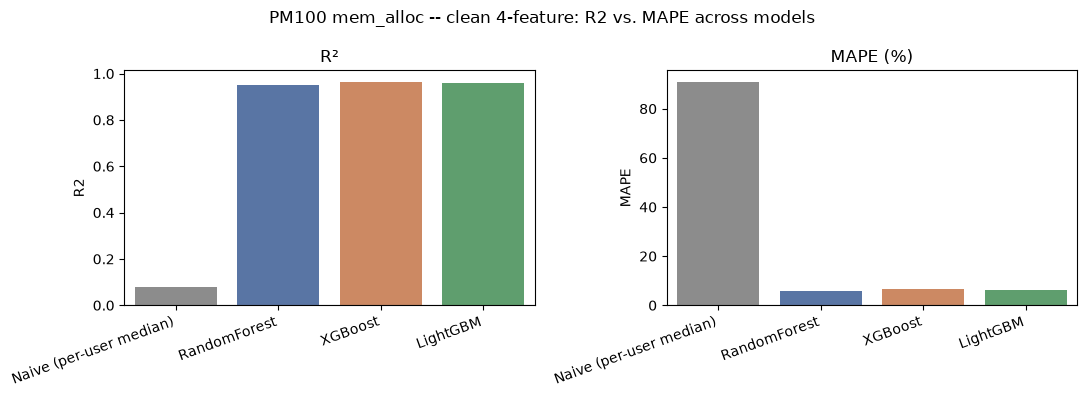

In [31]:
fig = plotting.plot_model_comparison(
    pm100_c4_summary_df, "PM100 mem_alloc -- clean 4-feature: R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

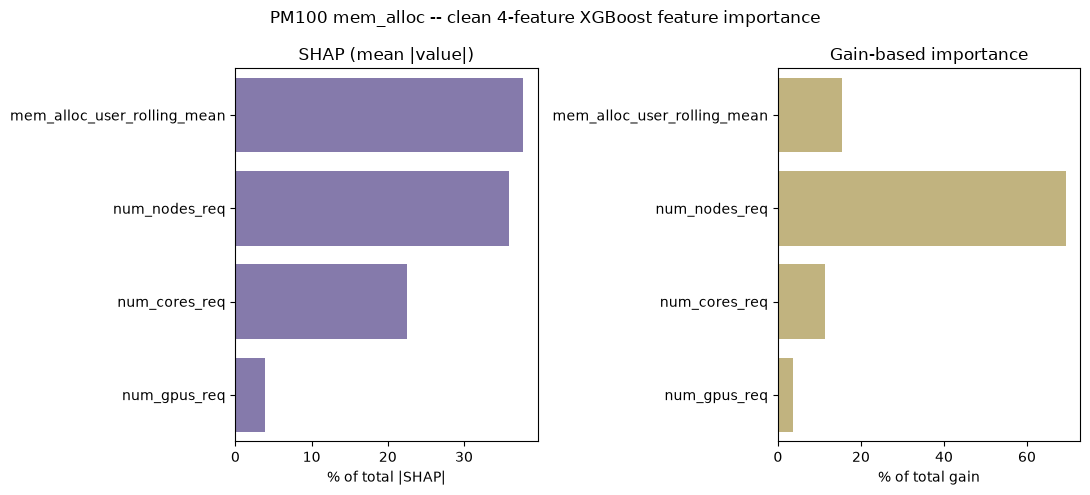

In [32]:
pm100_c4_gain = gain_importance_for(pm100_c4_best, pm100_c4_best_name, pm100_X_train_c4.columns)
_c4_explainer = shap.TreeExplainer(pm100_c4_best)
_c4_shap = _c4_explainer.shap_values(pm100_X_test_c4)
pm100_c4_shap = pd.Series(np.abs(_c4_shap).mean(axis=0), index=pm100_X_train_c4.columns)

fig = plotting.plot_feature_importance_comparison(
    pm100_c4_gain, pm100_c4_shap,
    f"PM100 mem_alloc -- clean 4-feature {pm100_c4_best_name} feature importance", top_n=10)
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

clean-4 correlation check on 4 columns: ['num_nodes_req', 'num_gpus_req', 'num_cores_req', 'mem_alloc_user_rolling_mean']


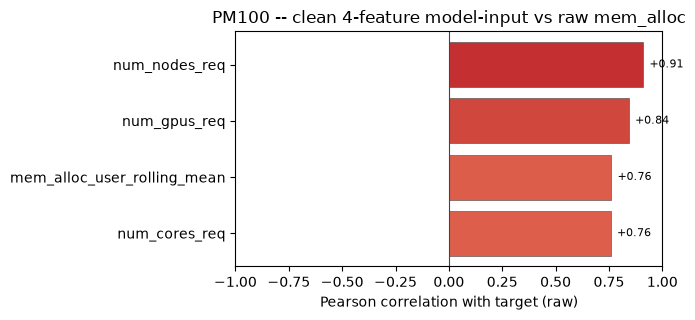

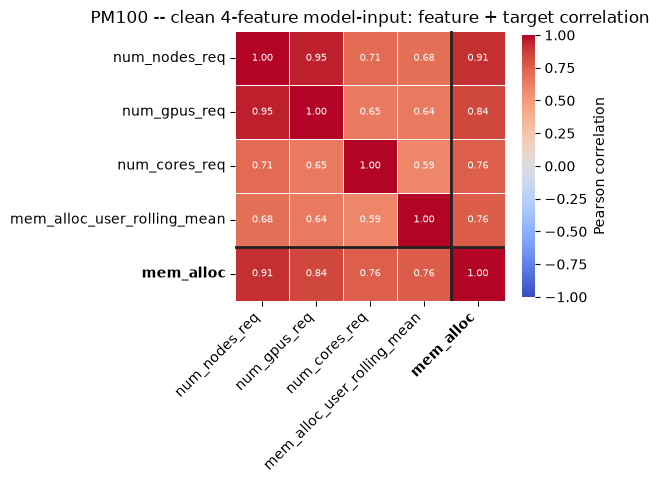

In [33]:
print(f"clean-4 correlation check on {pm100_X_train_c4.shape[1]} columns: {list(pm100_X_train_c4.columns)}")

fig = plotting.plot_feature_target_correlation(
    pm100_X_train_c4, pm100_y_train_raw,
    "PM100 -- clean 4-feature model-input vs raw mem_alloc")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    pm100_X_train_c4,
    "PM100 -- clean 4-feature model-input: feature + target correlation",
    target=pm100_y_train_raw, target_name="mem_alloc")
fig.savefig(FIGURES_DIR / "pm100_memory_clean4_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Part 2c Summary

Adopted feature set for PM100 memory, **all three models**: `num_nodes_req`, `num_gpus_req`, `num_cores_req`, `mem_alloc_user_rolling_mean` (`mem_req` and the other 12 production columns dropped). `best_params` from completed per-model 50-trial re-tunes on this exact 4-column set; no Optuna re-run in this section.

Rationale (full detail in the Part 2c header above): `mem_req` matches `mem_alloc` exactly on 93.76% of jobs, so with it present the models score high aggregate metrics by lookup while failing the ~6.24% of divergent jobs that genuine submission-time prediction targets. Verdict was reached per model: XGBoost unambiguous (full-17 divergent Within20% 17.9% -> clean-4 92.3%); RandomForest and LightGBM a deliberate tradeoff of ~2–4 aggregate R² points for far more reliable divergent-case accuracy.

The full-17 results (Step 27), stripped ablation (Step 28), and `pm100_memory_*.png` figures above are retained unchanged as the investigated-and-rejected record. Figures for the adopted models are `pm100_memory_clean4_*.png`.